In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections.abc import Callable

In [2]:
# nearest neighbor dipole interaction with pbc

LATTICE_VECTOR_1 = np.array([1,0,0])
LATTICE_VECTOR_2 = np.array([-1/2,np.sqrt(3)/2,0])
a3 = np.array([-1/2,-np.sqrt(3)/2,0])
a = np.stack((LATTICE_VECTOR_1, LATTICE_VECTOR_2, a3))
d = 1
def mat_nn(i: int,j: int,k: np.ndarray) -> float:
    
    fij = 0 
    for ai in a:
        fnu =0
        if i==j:
            fnu += 3
            if i == 2:
                fnu += 6*d
        fnu -= ai[i] * ai[j]* 15
        fnu *= np.exp(1j* np.dot(ai,k))
        # fnu *= np.cos(np.dot(ai,k))
        fij += fnu
    return fij

def mat33(i: int,j: int,k: np.ndarray) -> float:
    
    fij = 0 
    for ai in a:
        fnu =0
        if i==j:
            fnu += 3
            if i == 2:
                fnu += 6*d
        fnu -= ai[i] * ai[j]* 15
        # fnu *= np.exp(1j* np.dot(ai,k))
        fnu *= np.cos(np.dot(ai,k))
        fij += fnu
    return fij

def mat_gradient(i: int,j: int,k: np.ndarray,axis: int) -> float:
    if np.all(k == 0):
        return 0
    fij = 0 
    for ai in a:
        fnu =0
        if i==j:
            fnu += 3
            if i == 2:
                fnu += 6*d
        fnu -= ai[i] * ai[j]* 15
        fnu *= 1j* ai[axis]* np.exp(1j* np.dot(ai,k))
        fij += fnu
    return fij

def D_mat_nn(k: np.ndarray) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    dmat= np.zeros((6,6), dtype=complex)
    for i in range(6):
        for j in range(6):
            if i < 3 and j < 3:
               dmat[i, j] = -mat_nn(i, j, np.zeros(3))
            elif i >= 3 and j >= 3:
                dmat[i, j] = dmat[i-3, j-3]
            elif i < 3 and j >= 3:
                dmat[i, j] = mat_nn(i,j-3,k)
            elif i >= 3 and j < 3:
                dmat[i, j] = np.conjugate(mat_nn(i-3,j,k))
    return dmat

def D_mat33(k: np.ndarray) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    dmat= np.zeros((3,3), dtype=complex)
    for i in range(3):
        for j in range(3):
               dmat[i, j] = -mat33(i, j, np.zeros(3))
               dmat[i,j] += mat33(i,j,k)
            
    return dmat

def D_mat_gradient(k: np.ndarray) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    dmatx= np.zeros((6,6), dtype=complex)
    dmaty = np.zeros((6,6), dtype=complex)
    for i in range(6):
        for j in range(6):
            if i < 3 and j >= 3:
                dmatx[i, j] = mat_gradient(i,j-3,k,0)
                dmaty[i, j] = mat_gradient(i,j-3,k,1)
            elif i >= 3 and j < 3:
                dmatx[i, j] = np.conjugate(mat_gradient(i-3,j,k,0))
                dmaty[i, j] = np.conjugate(mat_gradient(i-3,j,k,1))
    return dmatx, dmaty
# ex = D_mat(np.array([1/2,1/2,0]))  # Example usage to compute D matrix for a specific k vector
# pd.DataFrame(ex, columns=[f'j{i}' for i in range(6)], index=[f'i{i}' for i in range(6)])  # Convert to DataFrame for better visualization
# for i in range(6):
#     for j in range(6):
#         print(f"{ex[i,j]:.2}", end='\t\t')
#     print()  # Print each row of the matrix on a new line


In [ ]:
k1 = np.zeros(3)
b = 4*np.pi/3/np.sqrt(3)
k2 = np.array([0,b,0])
k3 = b*np.array([np.sqrt(3)/4,3/4,0])

def k_course(t: float) -> np.ndarray:
    """Calculate the k vector based on the time parameter t."""
    if t < 1/3:
        return (1-t*3) * k3
    elif t < 2/3:
        return (t-1/3)*3* k2
    else:
        return (t-2/3)*3 * (k3-k2) + k2
    
# fig, ax  = plt.subplots(figsize=(8, 6))
t = np.linspace(0, 1,200)
eigs = np.zeros((len(t), 6,7), dtype=complex)

def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    eigenvectors *= np.conjugate(eigenvectors[0, :])/np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    sorted_comb = sorted(comb, key=lambda x: x[0])
    return np.array(sorted_comb)

eigs2 = np.zeros((len(t), 3,4), dtype=complex)
for i in range(len(t)):
    k = k_course(t[i])
    dmat = D_mat_nn(k)
    eigvals, eigvecs = np.linalg.eig(dmat)
    eigs[i, :] = sort_eigenvalues(eigvals, eigvecs)
    k_course2 = k2+np.array([1,0,0])*(-1/2+t[i])
    dmat2 = D_mat33(k)
    eigvals2, eigvecs2 = np.linalg.eig(dmat2)
    # eigs2[i, :] = sort_eigenvalues(eigvals2, eigvecs2)
    eigs2[i,:,0] = sorted(eigvals2)
    # Plot the k vector
    # ax.scatter(k[0], k[1], color='blue', s=10)
#     for eig in eigvals:
#         ax.scatter(x,eig,color='blue', s=10, alpha=0.5)
# plt.show()
 


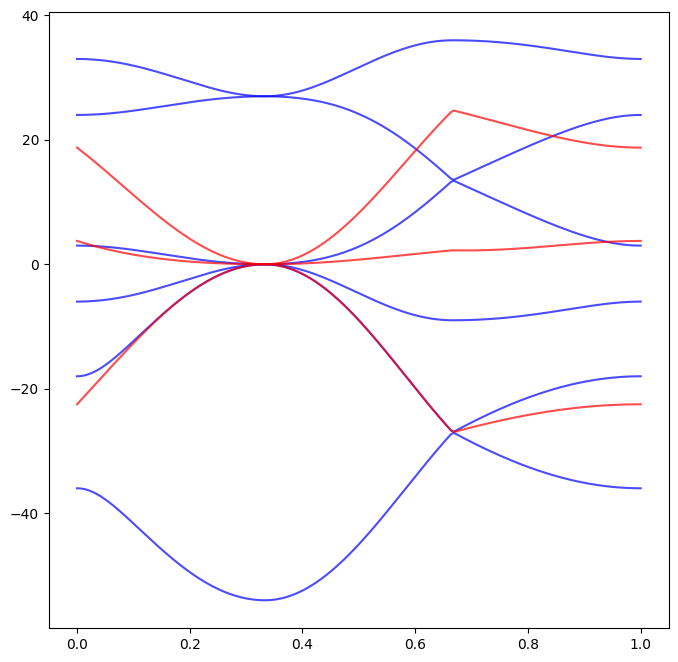

In [12]:
fig, ax = plt.subplots(1,1,figsize=(8, 8))
for i in range(6):
    ax.plot(t, eigs[:, i,0], label=f'Eigenvalue {i+1}',color='blue', alpha=0.7)
# for i in range(3):
#     ax.plot(t, eigs2[:,i,0], label=f'Eigenvalue {i+1}',color='red', alpha=0.7)
    # ax[0].plot(t, np.imag(eigs2[:, 3,i+1]), label=f'Eigenvalue {i+1}')#,color='blue', alpha=0.7)
plt.show()


In [ ]:
def Berry_curvature(k,band_index) -> np.ndarray:
    """Calculate the Berry curvature."""
    D_grad = D_mat_gradient(k)
    dmat0 = D_mat(k)
    eigvals0, eigvecs0 = np.linalg.eig(dmat0)
    eigs0 = sort_eigenvalues(eigvals0, eigvecs0)
    berry_curvature = 0
    # for i in range(eigs0.shape[0]):
    for i in range(3,4):
        if i == band_index:
            continue
        berry_curvature += 2*np.imag(np.tensordot(np.tensordot(np.conjugate(eigs0[band_index,1:]),D_grad[0],axes=(0,0)),eigs0[i,1:],axes=(0,0))\
                                     *np.tensordot(np.tensordot(np.conjugate(eigs0[i,1:]),D_grad[1],axes=(0,0)),eigs0[band_index,1:],axes=(0,0)))/(eigs0[band_index,0] - eigs0[i,0])**2
    return berry_curvature

def phase(k_vec,tol, band_index,delta_k) -> np.ndarray:
    """Calculate the phase of the eigenvector."""
    berry_phase = np.zeros(2)
    for i in range(2):
        delta = np.zeros(3)
        delta[i] = tol
        dmat1 = D_mat(k_vec+delta)
        dmat2 = D_mat(k_vec-delta)
        dmat0 = D_mat(k_vec)
        eigvals0, eigvecs0 = np.linalg.eig(dmat0)
        eigs0 = sort_eigenvalues(eigvals0, eigvecs0)
        eigvals1, eigvecs1 = np.linalg.eig(dmat1)
        eigvals2, eigvecs2 = np.linalg.eig(dmat2)
        eigs1 = sort_eigenvalues(eigvals1, eigvecs1)
        eigs2 = sort_eigenvalues(eigvals2, eigvecs2)
        # grad = (eigs1[band_index,1:] - eigs2[band_index,1:]) / (2*tol)
        # berry_phase[i] = -np.imag(np.dot(np.conjugate(eigs0[band_index,1:]), grad))
        berry_phase[i] = np.imag(np.dot(np.conjugate(eigs1[band_index,1:]), eigs0[band_index,1:])-np.dot(np.conjugate(eigs2[band_index,1:]), eigs0[band_index,1:]))/ (2*tol)
    
    berry_phase = berry_phase / np.linalg.norm(berry_phase)*3/4*delta_k
    return berry_phase

grid_size = 19
delta = 0.01
ky_env = np.linspace(b-delta, b+delta, grid_size)
kx_env = np.linspace(-delta, delta, grid_size)
# kx, ky = np.meshgrid(kx_env, ky_env)
# k = np.column_stack((kx, ky, np.zeros_like(kx)))
# eigenvalues = np.zeros((kx.shape[0], kx.shape[1], 6), dtype=complex)
# eigs = np.zeros((kx_env.shape[0], ky_env.shape[0], 6, 7))
phases_for_berry = np.zeros((kx_env.shape[0], kx_env.shape[0], 2))
phases_for_berry2 = np.zeros((kx_env.shape[0], kx_env.shape[0], 2))
B_curvature = np.zeros((kx_env.shape[0], kx_env.shape[0]))
for i in range(kx_env.shape[0]):
    for j in range(ky_env.shape[0]):
        phases_for_berry[i, j] = phase(np.array([kx_env[i],ky_env[j], 0]), 0.001, 4, kx_env[1]-kx_env[0])
        phases_for_berry2[i, j] = phase(np.array([kx_env[i],ky_env[j], 0]), 0.001, 3, kx_env[1]-kx_env[0])
        B_curvature[i, j] = Berry_curvature(np.array([kx_env[i],ky_env[j], 0]), 4)



/tmp/ipykernel_30595/2763962305.py:54: ComplexWarning: Casting complex values to real discards the imaginary part
  B_curvature[i, j] = Berry_curvature(np.array([kx_env[i],ky_env[j], 0]), 4)


In [142]:
def curvature_wrapper(kx,ky):
    """Wrapper function to calculate the curvature."""
    k = np.array([kx, ky, 0])
    return Berry_curvature(k, 4)
from scipy.integrate import dblquad
dblquad(curvature_wrapper, kx_env[0], kx_env[-1], lambda x: ky_env[0], lambda x: ky_env[-1])

/tmp/ipykernel_30595/729845650.py:21: RuntimeWarning: invalid value encountered in divide
  eigenvectors *= np.conjugate(eigenvectors[0, :])/np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
/home/christian/Documents/master/numerics/python_env/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:607: ComplexWarning: Casting complex values to real discards the imaginary part
  return _quadpack._qagse(func,a,b,args,full_output,epsabs,epsrel,limit)
/home/christian/Documents/master/numerics/python_env/lib/python3.12/site-packages/scipy/integrate/_quadpack_py.py:1264: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and cal

KeyboardInterrupt: 

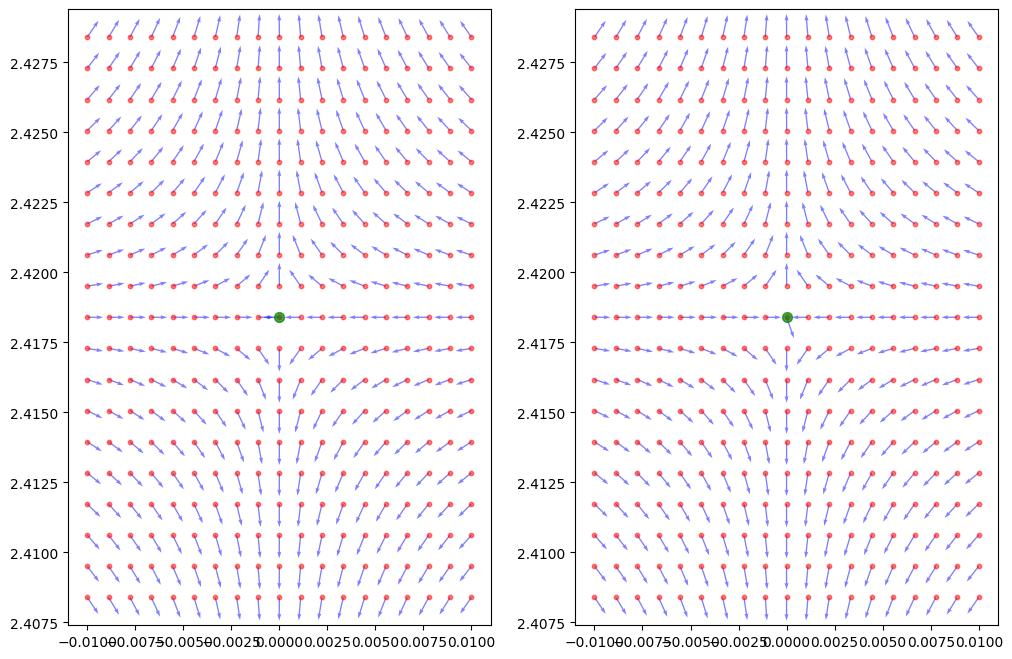

In [171]:
fig, ax = plt.subplots(1,2,figsize=(12, 8))
scale = 1
q = ax[0].quiver(kx_env,ky_env, phases_for_berry[:,:,0]*scale, phases_for_berry[:,:,1]*scale, 
               angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.5)
ax[1].quiver(kx_env,ky_env, phases_for_berry2[:,:,0]*scale, phases_for_berry2[:,:,1]*scale, 
               angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.5)
for i in range(kx_env.shape[0]):
    for j in range(ky_env.shape[0]):
        ax[0].scatter(kx_env[i], ky_env[j], color='red', s=10, alpha=0.5)
        ax[1].scatter(kx_env[i], ky_env[j], color='red', s=10, alpha=0.5)
ax[0].scatter(np.mean(kx_env), np.mean(ky_env), color='green', s=50, label='K point', alpha=0.7)
ax[1].scatter(np.mean(kx_env), np.mean(ky_env), color='green', s=50, label='K point', alpha=0.7)
plt.show()

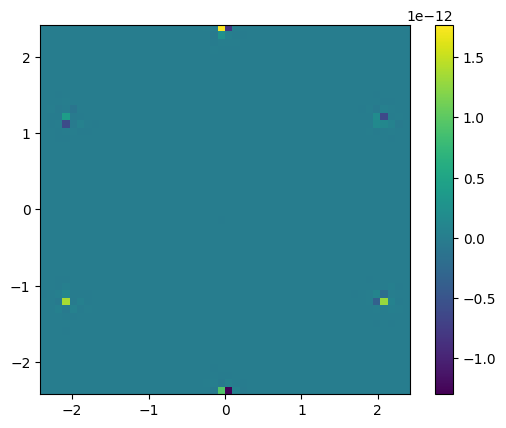

In [149]:
fig, ax = plt.subplots(1,1)
im = ax.imshow(B_curvature.T, extent=(kx_env[0], kx_env[-1], ky_env[0], ky_env[-1]), origin='lower', cmap='viridis')
cbar = plt.colorbar(im, ax=ax)

In [3]:
# interaction and lattice definition

BASE_A = np.zeros(3)
BASE_B = np.array([1/np.sqrt(3),0,0])
LATTICE_VECTOR_2 = np.array([0,1,0])
LATTICE_VECTOR_1 = 1/2*np.array([np.sqrt(3),1,0])
LATTICE_VECTOR_1_ALTERNATIVE = np.sqrt(3)*np.array([1,0,0])

REZI_2 = 2*np.pi/np.sqrt(3)*np.array([-1,np.sqrt(3),0])   
REZI_1 = 4*np.pi/np.sqrt(3)*np.array([1,0,0])
# alternative can't be used, gives wrong results
REZI_1_ALTERNATIVE = 2*np.pi/np.sqrt(3)*np.array([1,0,0])
REZI_2_ALTERNATIVE = 2*np.pi*np.array([0,1,0])


def bare_interaction(Delta_R_vec: np.ndarray, i: int, j: int, interaction_radius: float) -> float:
    """Calculate the bare interaction between two dipoles."""
    Delta_R_vec /= 5
    Del_R = np.linalg.norm(Delta_R_vec)
    # if Del_R > np.sqrt(3)+0.01:
    # if Del_R > 1.01:
    if Del_R >interaction_radius+0.01:
        return 0
    potential = 0
    if i == j:
        potential += 3/ Del_R**5
        if i == 2:
            potential += 6/ Del_R**5
    potential -= 15/Del_R**7 *Delta_R_vec[i] * Delta_R_vec[j]
    return potential

def bare_interaction_coulomb(Delta_R_vec: np.ndarray, i: int, j:int, interaction_radius: np.float64) -> np.float64:
    beta = 0.04
    potential = 0 
    Del_R = np.linalg.norm(Delta_R_vec)
    if Del_R >interaction_radius+0.01:
        return 0
    if i==j:
        # return 0
        potential += 1
    potential -= 3*Delta_R_vec[i]*Delta_R_vec[j]/Del_R**2
    potential *= beta/2/Del_R**3
    return potential
        

def bare_interaction_coulomb_onsite(i: int, j:int) -> float:
    Vb = -0.1
    if i ==2 or j==2:
        return 0
    elif i == j:
        return 1
    elif i ==0:
        return -1j*Vb
    else:
        return 1j*Vb
    
def no_onsite_interaction(i: int, j:int) -> float:
    return 0

b = 4*np.pi/3/np.sqrt(3)
k3 = b*np.array([np.sqrt(3)/4,3/4,0])
k1 = 2*np.pi/3*np.array([-1,np.sqrt(3),0])   
k2 = 4*np.pi/3*np.array([1,0,0])

def k_course(t: float) -> np.ndarray:
    """Calculate the k vector based on the time parameter t."""
    if t < 1/3:
        return (1-t*3) * k3
    elif t < 2/3:
        return (t-1/3)*3* k2
    else:
        return (t-2/3)*3 * (k3-k2) + k2

In [5]:
# cylindric boundaries
def Hamiltonian_momentum_same_grid(i,j,n,m,k,interaction,onsite_interaction,latticeA,latticeB,cut):

    potentialAB = 0
    potentialAA = 0
    grid_size = latticeA.shape[2]
  
    for h in range(grid_size):
        Del_RAB = latticeB[:,m,h] - latticeA[:,n,grid_size//2]
        if i!=j:
            potentialAB -= interaction(Del_RAB,i,j,cut)
        if n==m and h==grid_size//2:
            potentialAA += onsite_interaction(i,j)
            continue
        Del_RAA = latticeA[:,m,h] - latticeA[:,n,grid_size//2]
        
        potential = interaction(Del_RAA,i,j,cut)#*(np.exp(-1j * np.dot(Del_RAA,k))-1)
        potentialAA += potential *np.exp(-1j * np.dot(Del_RAA,k))
        if i!=j:
            potentialAA -= potential
        
    # Fourier_vector = np.exp(-1j *np.arange(-grid_size//2,grid_size//2+1)*np.dot(A1,k))
    # interaction_mat = np.sum(interaction_mat*Fourier_vector,axis=0)
    return potentialAA+potentialAB

def Hamiltonian_momentum_mixed_grid(i,j,n,m,k,interaction,latticeA,latticeB,cut):
    potentialAB = 0

    grid_size = latticeA.shape[2]
  
    for h in range(grid_size):
        Del_RAB = latticeB[:,m,h] - latticeA[:,n,grid_size//2]
        Del_Fourier = latticeA[:,m,h] - latticeA[:,n,grid_size//2]
        potentialAB += interaction(Del_RAB,i,j,cut)*np.exp(-1j * np.dot(Del_Fourier,k))

    return potentialAB

def cylindric_Dmat(k,interaction,onsite_interaction,grid_size,*cut):  
    """neccessary to plug in even grid size"""  
    latticeA = np.zeros((3,grid_size,grid_size))
    latticeB = np.zeros_like(latticeA)
    BASE_B2 = 1/np.sqrt(3)*np.array([-1/2, np.sqrt(3)/2, 0])+LATTICE_VECTOR_1_ALTERNATIVE
    BASE_A2 = LATTICE_VECTOR_1
    # LATTICE_VECTOR_1_ALTERNATIVE = 3*np.array([1/np.sqrt(3),0,0])
    for i in range(grid_size//2):
        latticeA[:,2*i+1,0] = BASE_A2 + i * LATTICE_VECTOR_1_ALTERNATIVE 
        latticeA[:,2*i,0] = BASE_A + i * LATTICE_VECTOR_1_ALTERNATIVE   

        latticeB[:,2*i,0] = BASE_B + i * LATTICE_VECTOR_1_ALTERNATIVE 
        latticeB[:,2*i+1,0] = BASE_B2 + i * LATTICE_VECTOR_1_ALTERNATIVE 
        for j in range(1,grid_size):
            latticeA[:,2*i+1,j] = latticeA[:,2*i+1,0] + j*LATTICE_VECTOR_2
            latticeB[:,2*i+1,j] = latticeB[:,2*i+1,0] + j*LATTICE_VECTOR_2

            latticeA[:,2*i,j] = latticeA[:,2*i,0] + j*LATTICE_VECTOR_2
            latticeB[:,2*i,j] = latticeB[:,2*i,0] + j*LATTICE_VECTOR_2

            
    dmat = np.zeros((6*grid_size,6*grid_size),dtype=complex)
    if not cut:
        cut = [grid_size*4/9*np.sqrt(3)*10**2]
    for i in range(6):
        for j in range(6):
            if i <3 and j<3:
                for n in range(grid_size):
                    for m in range(grid_size):
                        dmat[i*grid_size+n,j*grid_size+m] = Hamiltonian_momentum_same_grid(i,j,n,m,k,interaction,onsite_interaction,latticeA,latticeB,*cut)
            if i >=3 and j>=3:
                for n in range(grid_size):
                    for m in range(grid_size):
                        dmat[i*grid_size+n,j*grid_size+m] = Hamiltonian_momentum_same_grid(i-3,j-3,n,m,k,interaction,onsite_interaction,latticeB,latticeA,*cut)
            if i <3 and j>=3:
                for n in range(grid_size):
                    for m in range(grid_size):
                        dmat[i*grid_size+n,j*grid_size+m] = Hamiltonian_momentum_mixed_grid(i,j-3,n,m,k,interaction,latticeA,latticeB,*cut)
            if i >=3 and j<3:
                for n in range(grid_size):
                    for m in range(grid_size):
                        dmat[i*grid_size+n,j*grid_size+m] = Hamiltonian_momentum_mixed_grid(i-3,j,n,m,k,interaction,latticeB,latticeA,*cut)
    return dmat




191 0


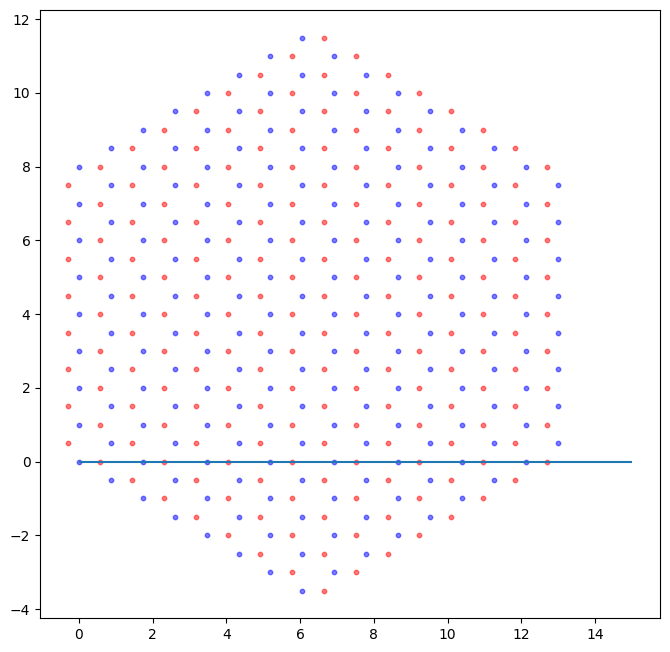

In [14]:
# create open honeycomb lattice 

def mat_size(n):
    # return 2*((n+1)*(n-1)+n*(n-1)+2*n**2)
    # return 2*((n+1)*n+n**2+(n+2)*n+n)
    # return 2*((n+1)**2+(n-1)*(n+1)/2+3/2*(n+1)-n-1)
    return 2*((n+1)**2+n//2+n*(n//2+1)-n-1)


fig, ax = plt.subplots(1,1,figsize=(8, 8))
grid_size = 7
latticeA = np.zeros((3,mat_size(grid_size)*3))#2*grid_size*(grid_size+1)+((grid_size-1)*grid_size-grid_size+3)*2))
latticeB = np.zeros_like(latticeA)
BASE_B2 = 1/np.sqrt(3)*np.array([-1/2, np.sqrt(3)/2, 0])
LATTICE_VECTOR_1_DOWN = 1/2*np.array([np.sqrt(3),-1,0])
BASE_A2 = LATTICE_VECTOR_1
# LATTICE_VECTOR_1_ALTERNATIVE = np.array([1/np.sqrt(3),0,0])
count = -1
for j in range(grid_size+1):
    for i in range(grid_size+1):
        count += 1
        # ax.scatter(2*i+grid_size//2+1,j,color='blue',s=10,alpha=0.5)
        # ax.scatter(2*i+1+grid_size//2+1,j,color='blue',s=10,alpha=0.5)
        latticeA[:,count] = BASE_A2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
        latticeB[:,count] = BASE_B2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
for j in range(grid_size):
    for i in range(grid_size+1):
        count += 1
        latticeA[:,count] = LATTICE_VECTOR_2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
        latticeB[:,count] = BASE_B+ LATTICE_VECTOR_2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2

for i in range(grid_size+1):
    for j in range(i//2+1):
        count += 1
        latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN + j*LATTICE_VECTOR_2
        latticeA[:,count] = BASE_A+  i * LATTICE_VECTOR_1_DOWN + j*LATTICE_VECTOR_2
# for j in range(1,grid_size//2+1):
#     count += 1
#     latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_1_DOWN*(grid_size+1)+j * LATTICE_VECTOR_2
#     latticeA[:,count] = BASE_A+ LATTICE_VECTOR_1_DOWN*grid_size+j * LATTICE_VECTOR_2

for i in range(grid_size):
    for j in range((grid_size-i-1)//2+1):
        count += 1
        latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_1_DOWN*(grid_size+1)+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2

        latticeA[:,count] = BASE_A+ LATTICE_VECTOR_1_DOWN*grid_size+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2


for i in range(grid_size+1):
    for j in range(i//2+1):
        count += 1
        latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_2*grid_size+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 - j*LATTICE_VECTOR_2
        latticeA[:,count] = BASE_A + (grid_size+1)* LATTICE_VECTOR_2 +  i * LATTICE_VECTOR_1 - j*LATTICE_VECTOR_2
# for j in range(1,grid_size//2+1):
#     count += 1
#     latticeB[:,count] = BASE_B2+  LATTICE_VECTOR_2*grid_size+ LATTICE_VECTOR_1*(grid_size+1)-j * LATTICE_VECTOR_2
#     latticeA[:,count] = BASE_A + (grid_size+1)* LATTICE_VECTOR_2+ LATTICE_VECTOR_1*grid_size-j * LATTICE_VECTOR_2

for i in range(grid_size):
    for j in range((grid_size-i-1)//2+1):
        count += 1
        latticeB[:,count] = BASE_B2+  LATTICE_VECTOR_2*grid_size+ LATTICE_VECTOR_1*(grid_size+1) + LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN - j*LATTICE_VECTOR_2

        latticeA[:,count] = BASE_A + (grid_size+1)* LATTICE_VECTOR_2+ LATTICE_VECTOR_1*grid_size+ LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN - j*LATTICE_VECTOR_2

count_eq = 0
for i in range(count+1):
    for j in range(count+1):
        
        # if i!=j and latticeA[0,j]==latticeA[0,i] and latticeA[1,j]==latticeA[1,i] :
        if i!=j and latticeB[0,j]==latticeB[0,i] and latticeB[1,j]==latticeB[1,i] :
            count_eq += 1
print (count,count_eq)

        # latticeA[:,i*grid_size+2*j+1] = BASE_A2 + i * LATTICE_VECTOR_1_ALTERNATIVE   + j * LATTICE_VECTOR_2
    # latticeA[:,grid_size*i+grid_size-1] = BASE_A + i * LATTICE_VECTOR_1_ALTERNATIVE + (grid_size-1)*LATTICE_VECTOR_2
    # ax.scatter(grid_size-1+grid_size//2+1,j,color='blue',s=10,alpha=0.5) 
   
# for j in range(grid_size//2+1):
#     for i in range(j+1):
#         # latticeA[:,i,j] = i* BASE_B2 + j * LATTICE_VECTOR_2
#         ax.scatter(i,j,color='red',s=10,alpha=0.5)
        
#         # latticeA[:,i]
# for j in range(grid_size//2+1,grid_size):
#     for i in range(grid_size//2+1+j-grid_size):
#         # latticeA[:,1-j+i-grid_size,grid_size-j] = (grid_size//2+1-i)* BASE_B2 + j * LATTICE_VECTOR_2
#         ax.scatter(grid_size//2-i,grid_size-j-1,color='green',s=10,alpha=0.5)
        

# for j in range(grid_size//2+1,grid_size+1):
#     for i in range(grid_size//2+1+j-grid_size):
#         ax.scatter(i,j,color='orange',s=10,alpha=0.5)


# for j in range(grid_size//2+1,grid_size):
#     for i in range(grid_size-j):
#         ax.scatter(grid_size//2-i,j,color='0',s=10,alpha=0.5)




        


for i in range(count+1):
    # for j in range(grid_size):
        ax.scatter(latticeA[0,i], latticeA[1,i], color='blue', s=10, alpha=0.5)
        ax.scatter(latticeB[0,i], latticeB[1,i], color='red', s=10, alpha=0.5)
ax.hlines(0,0,15)
ax.set_aspect('equal', adjustable='box')

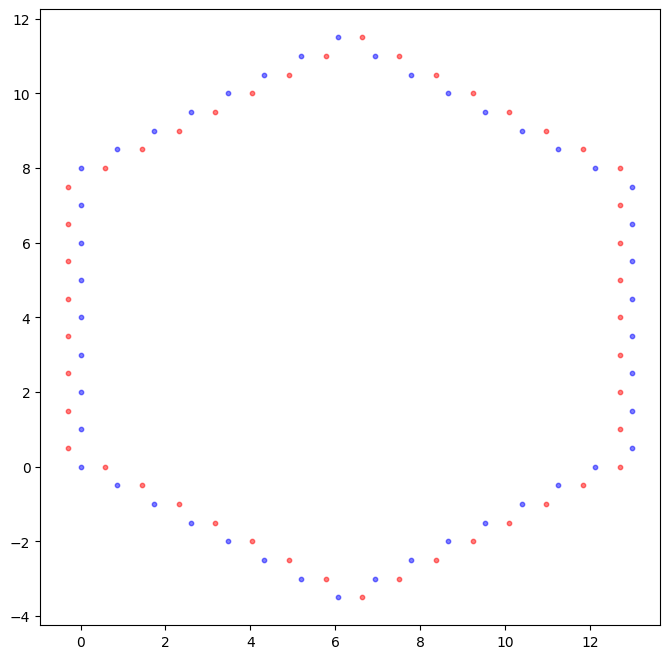

In [17]:
fig, ax = plt.subplots(1,1,figsize=(8,8))
# for j in range(grid_size+1):
#     plt.scatter(latticeA[0,j],latticeA[1,j],color='blue',s=10,alpha=0.5)
#     plt.scatter(latticeB[0,j],latticeB[1,j],color='red',s=10,alpha=0.5)
# for j in range(grid_size*(grid_size+1),(grid_size+1)*(grid_size+1)):
#     plt.scatter(latticeA[0,j],latticeA[1,j],color='blue',s=10,alpha=0.5)
#     plt.scatter(latticeB[0,j],latticeB[1,j],color='red',s=10,alpha=0.5)

# # plt.show()
edge_A = []
edge_B = []
# count = (2*grid_size+1)*(grid_size+1)-1
# for i in range(grid_size+1):
    
#     for j in range(i//2+1):
#         count += 1
#     plt.scatter(latticeA[0,count],latticeA[1,count],color='blue',s=10,alpha=0.5)
#     plt.scatter(latticeB[0,count],latticeB[1,count],color='red',s=10,alpha=0.5)
count = -1
for j in range(grid_size+1):
    # plt.scatter(latticeA[0,count+1],latticeA[1,count+1],color='blue',s=10,alpha=0.5)
    plt.scatter(latticeB[0,count+1],latticeB[1,count+1],color='red',s=10,alpha=0.5)
    edge_B.append(count+1)
    for i in range(grid_size+1):
        count += 1
    plt.scatter(latticeA[0,count],latticeA[1,count],color='blue',s=10,alpha=0.5)
    edge_A.append(count)
    # plt.scatter(latticeB[0,count],latticeB[1,count],color='red',s=10,alpha=0.5)
        # latticeA[:,count] = BASE_A2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
        # latticeB[:,count] = BASE_B2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
for j in range(grid_size):
    plt.scatter(latticeA[0,count+1],latticeA[1,count+1],color='blue',s=10,alpha=0.5)
    edge_A.append(count+1)
    for i in range(grid_size+1):
        count += 1
    # plt.scatter(latticeA[0,count],latticeA[1,count],color='blue',s=10,alpha=0.5)
    plt.scatter(latticeB[0,count],latticeB[1,count],color='red',s=10,alpha=0.5)
    edge_B.append(count)
        # latticeA[:,count] = LATTICE_VECTOR_2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
        # latticeB[:,count] = BASE_B+ LATTICE_VECTOR_2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2

for i in range(grid_size+1):
    edge_A.append(count+1)
    edge_B.append(count+1)
    plt.scatter(latticeA[0,count+1],latticeA[1,count+1],color='blue',s=10,alpha=0.5)
    plt.scatter(latticeB[0,count+1],latticeB[1,count+1],color='red',s=10,alpha=0.5)
    for j in range(i//2+1):
        count += 1
        # latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN + j*LATTICE_VECTOR_2
        # latticeA[:,count] = BASE_A+  i * LATTICE_VECTOR_1_DOWN + j*LATTICE_VECTOR_2


for i in range(grid_size):
    edge_A.append(count+1)
    edge_B.append(count+1)
    plt.scatter(latticeA[0,count+1],latticeA[1,count+1],color='blue',s=10,alpha=0.5)
    plt.scatter(latticeB[0,count+1],latticeB[1,count+1],color='red',s=10,alpha=0.5)
    for j in range((grid_size-i-1)//2+1):
        count += 1
        # latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_1_DOWN*(grid_size+1)+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
        # latticeA[:,count] = BASE_A+ LATTICE_VECTOR_1_DOWN*grid_size+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2


for i in range(grid_size+1):
    edge_A.append(count+1)
    edge_B.append(count+1)
    plt.scatter(latticeA[0,count+1],latticeA[1,count+1],color='blue',s=10,alpha=0.5)
    plt.scatter(latticeB[0,count+1],latticeB[1,count+1],color='red',s=10,alpha=0.5)
    for j in range(i//2+1):
        count += 1
#         latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_2*grid_size+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 - j*LATTICE_VECTOR_2
#         latticeA[:,count] = BASE_A + (grid_size+1)* LATTICE_VECTOR_2 +  i * LATTICE_VECTOR_1 - j*LATTICE_VECTOR_2

for i in range(grid_size):
    edge_A.append(count+1)
    edge_B.append(count+1)
    plt.scatter(latticeA[0,count+1],latticeA[1,count+1],color='blue',s=10,alpha=0.5)
    plt.scatter(latticeB[0,count+1],latticeB[1,count+1],color='red',s=10,alpha=0.5)
    for j in range((grid_size-i-1)//2+1):
        count += 1
#         latticeB[:,count] = BASE_B2+  LATTICE_VECTOR_2*grid_size+ LATTICE_VECTOR_1*(grid_size+1) + LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN - j*LATTICE_VECTOR_2
#         latticeA[:,count] = BASE_A + (grid_size+1)* LATTICE_VECTOR_2+ LATTICE_VECTOR_1*grid_size+ LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN - j*LATTICE_VECTOR_2
    


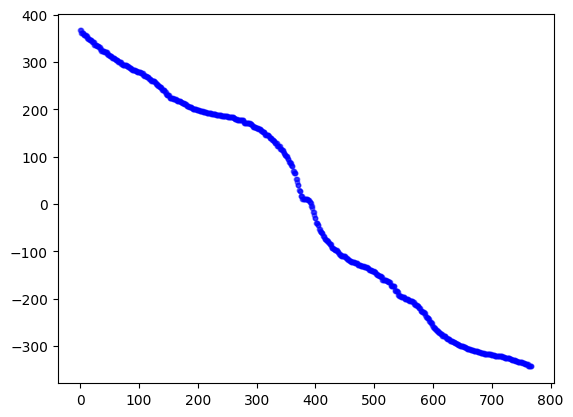

In [15]:
# open lattice consideration

def open_D_mat(grid_size,interaction,onsite_interaction,*cut):
    latticeA = np.zeros((3,mat_size(grid_size)*3))
    latticeB = np.zeros_like(latticeA)
    BASE_B2 = 1/np.sqrt(3)*np.array([-1/2, np.sqrt(3)/2, 0])
    LATTICE_VECTOR_1_DOWN = 1/2*np.array([np.sqrt(3),-1,0])
    BASE_A2 = LATTICE_VECTOR_1
    edge_A = []
    edge_B = []
    count = -1
    for j in range(grid_size+1):
        edge_B.append(count+1)
        for i in range(grid_size+1):
            count += 1

            latticeA[:,count] = BASE_A2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
            latticeB[:,count] = BASE_B2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
        edge_A.append(count)
    for j in range(grid_size):
        edge_A.append(count+1)
        for i in range(grid_size+1):
            count += 1
            latticeA[:,count] = LATTICE_VECTOR_2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
            latticeB[:,count] = BASE_B+ LATTICE_VECTOR_2 + i * LATTICE_VECTOR_1_ALTERNATIVE + j*LATTICE_VECTOR_2
        edge_B.append(count)


    for i in range(grid_size+1):
        edge_A.append(count+1)
        edge_B.append(count+1)
        for j in range(i//2+1):
            count += 1
            latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN + j*LATTICE_VECTOR_2
            latticeA[:,count] = BASE_A+  i * LATTICE_VECTOR_1_DOWN + j*LATTICE_VECTOR_2


    for i in range(grid_size):
        edge_A.append(count+1)
        edge_B.append(count+1)
        for j in range((grid_size-i-1)//2+1):
            count += 1
            latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_1_DOWN*(grid_size+1)+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
            latticeA[:,count] = BASE_A+ LATTICE_VECTOR_1_DOWN*grid_size+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2


    for i in range(grid_size+1):
        edge_A.append(count+1)
        edge_B.append(count+1)
        for j in range(i//2+1):
            count += 1
            latticeB[:,count] = BASE_B2+ LATTICE_VECTOR_2*grid_size+ LATTICE_VECTOR_1 + i * LATTICE_VECTOR_1 - j*LATTICE_VECTOR_2
            latticeA[:,count] = BASE_A + (grid_size+1)* LATTICE_VECTOR_2 +  i * LATTICE_VECTOR_1 - j*LATTICE_VECTOR_2

    for i in range(grid_size):
        edge_A.append(count+1)
        edge_B.append(count+1)
        for j in range((grid_size-i-1)//2+1):
            count += 1
            latticeB[:,count] = BASE_B2+  LATTICE_VECTOR_2*grid_size+ LATTICE_VECTOR_1*(grid_size+1) + LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN - j*LATTICE_VECTOR_2
            latticeA[:,count] = BASE_A + (grid_size+1)* LATTICE_VECTOR_2+ LATTICE_VECTOR_1*grid_size+ LATTICE_VECTOR_1_DOWN + i * LATTICE_VECTOR_1_DOWN - j*LATTICE_VECTOR_2
    

    latticeA = latticeA[:,:count+1]
    latticeB = latticeB[:,:count+1]
    dmat = np.zeros((4*(count+1),4*(count+1)),dtype=complex)
    if not cut:
        cut = [grid_size*4/9*np.sqrt(3)]
    for i in range(4):
        for j in range(4):
            if i <2 and j<2:
                for n in range(count+1):
                    for m in range(count+1):
                        if n==m:
                            dmat[i*(count+1)+n,j*(count+1)+m] = onsite_interaction(i,j)
                            continue
                        Del_R = latticeA[:,m]-latticeA[:,n]
                        dmat[i*(count+1)+n,j*(count+1)+m] = interaction(Del_R,i,j,*cut)
            if i >=2 and j>=2:
                for n in range(count+1):
                    for m in range(count+1):
                        if n==m:
                            dmat[i*(count+1)+n,j*(count+1)+m] = onsite_interaction(i-2,j-2)
                            continue
                        Del_R = latticeB[:,m]-latticeB[:,n]
                        dmat[i*(count+1)+n,j*(count+1)+m] = interaction(Del_R,i-2,j-2,*cut)
            if i <2 and j>=2:
                for n in range(count+1):
                    for m in range(count+1):
                        Del_R = latticeB[:,m]-latticeA[:,n]
                        dmat[i*(count+1)+n,j*(count+1)+m] = interaction(Del_R,i,j-2,*cut)
            if i >=2 and j<2:
                for n in range(count+1):
                    for m in range(count+1):
                        Del_R = latticeA[:,m]-latticeB[:,n]
                        dmat[i*(count+1)+n,j*(count+1)+m] = interaction(Del_R,i-2,j,*cut)
    return dmat, latticeA, latticeB, latticeA.shape[1], edge_A, edge_B


# dmat, latticeA, latticeB, lattice_size = open_D_mat(7,bare_interaction_coulomb,bare_interaction_coulomb_onsite,100)
dmat, latticeA, latticeB, lattice_size, edge_A, edge_B = open_D_mat(7,bare_interaction,no_onsite_interaction,100)
eig, vecs = np.linalg.eig(dmat)

fig, ax = plt.subplots(1,1)
ax.scatter(np.arange(eig.shape[0]), sorted(np.real(eig))[::-1], color='blue', s=10, alpha=0.5)
plt.show()


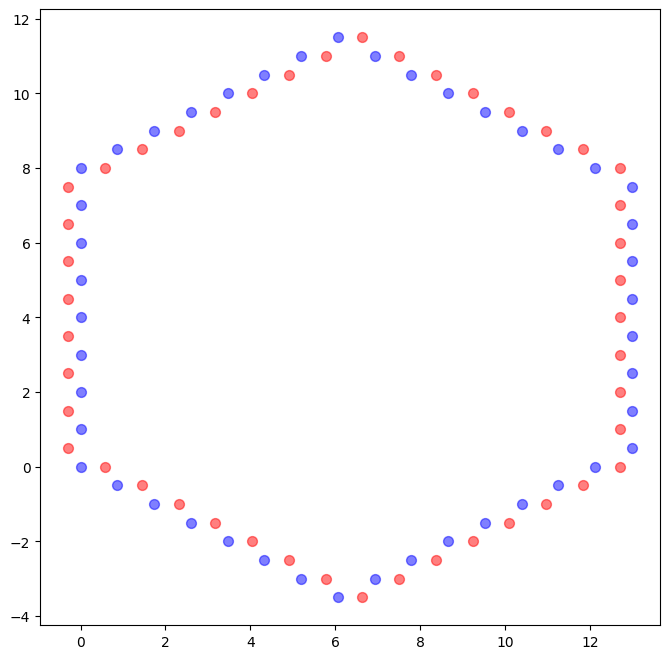

In [17]:
fig, ax = plt.subplots(1,1,figsize=(8, 8))
for i in range(len(edge_A)):
    ax.scatter(latticeA[0,edge_A[i]], latticeA[1,edge_A[i]], color='blue', s=50, alpha=0.5)
for i in range(len(edge_B)):
    ax.scatter(latticeB[0,edge_B[i]], latticeB[1,edge_B[i]], color='red', s=50, alpha=0.5)

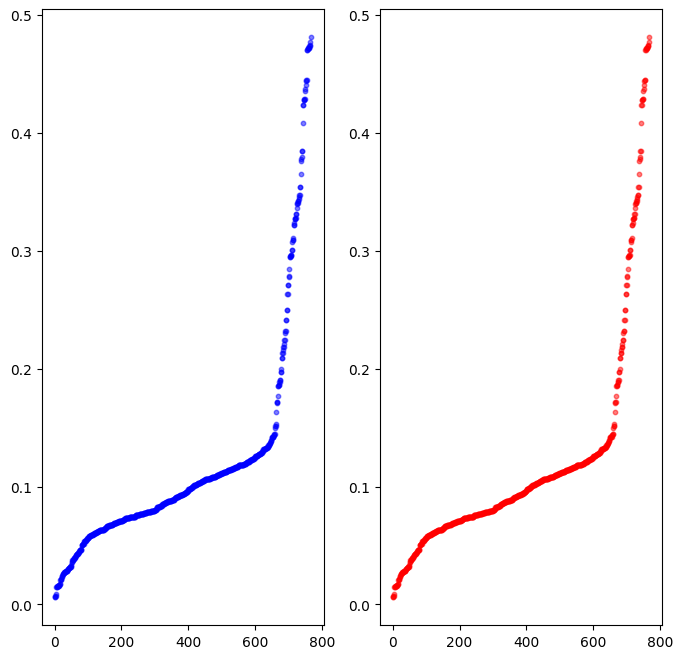

In [ ]:
def sum_edge(state, edge_A, edge_B):
    sum_A = 0
    sum_B = 0
    for i in range(len(edge_A)):
        sum_A += np.abs(state[edge_A[i]])**2 + np.abs(state[edge_A[i]+lattice_size])**2
    for i in range(len(edge_B)):
        sum_B += np.abs(state[edge_B[i]+2*lattice_size])**2 + np.abs(state[edge_B[i]+lattice_size*3])**2
    return sum_A, sum_B

vecs = sort_eigenvalues(eig,vecs)

fig, ax = plt.subplots(1,2,figsize=(8, 8))
edge_pops_A = []
edge_pops_B = []
for n in range(eig.shape[0]):
    ea,eb = sum_edge(vecs[n,1:], edge_A, edge_B)
    edge_pops_A.append(ea)
    edge_pops_B.append(eb)
ax[0].scatter(np.arange(eig.shape[0]), sorted(edge_pops_A), color='blue', s=10, alpha=0.5)
ax[1].scatter(np.arange(eig.shape[0]), sorted(edge_pops_B), color='red', s=10, alpha=0.5)

energy:  (9.44595317865484+0j)


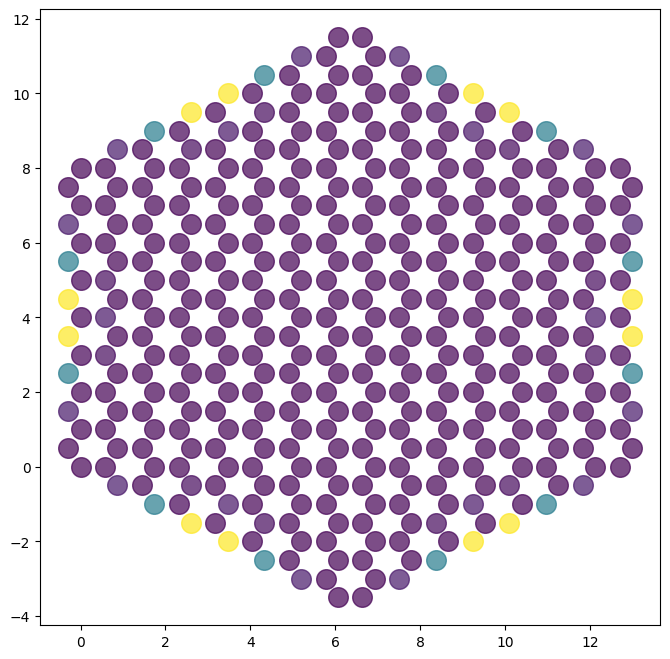

energy:  (9.794483715914879+0j)


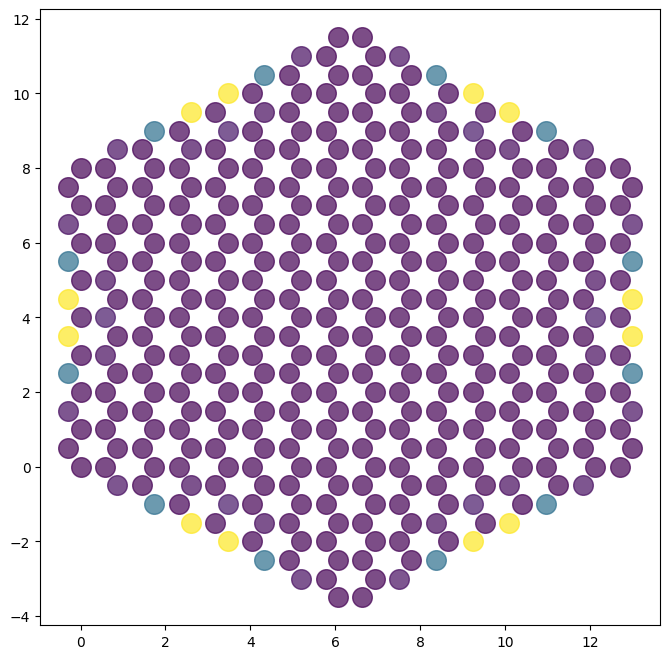

energy:  (197.63546504205317-0j)


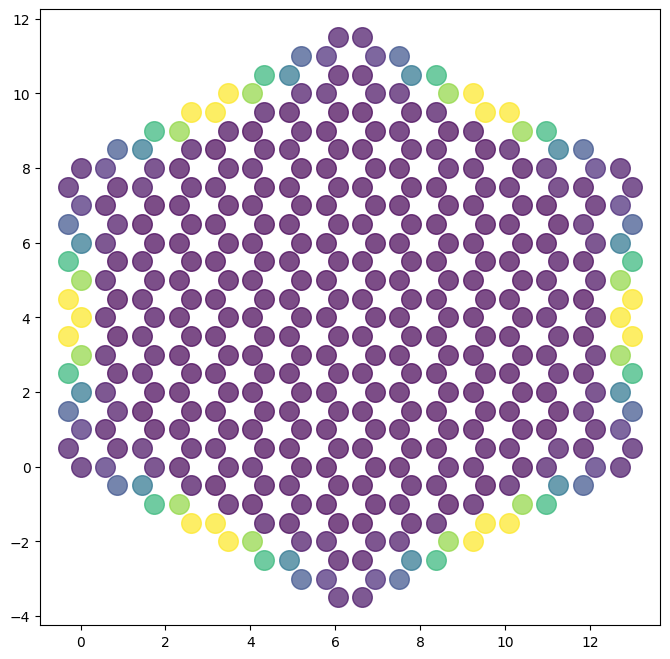

energy:  (9.771527865742819+0j)


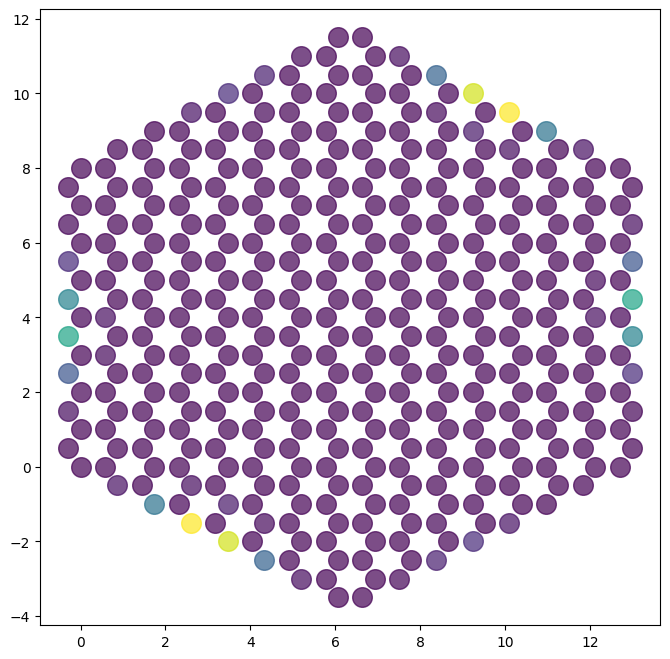

energy:  (9.771527865742032+0j)


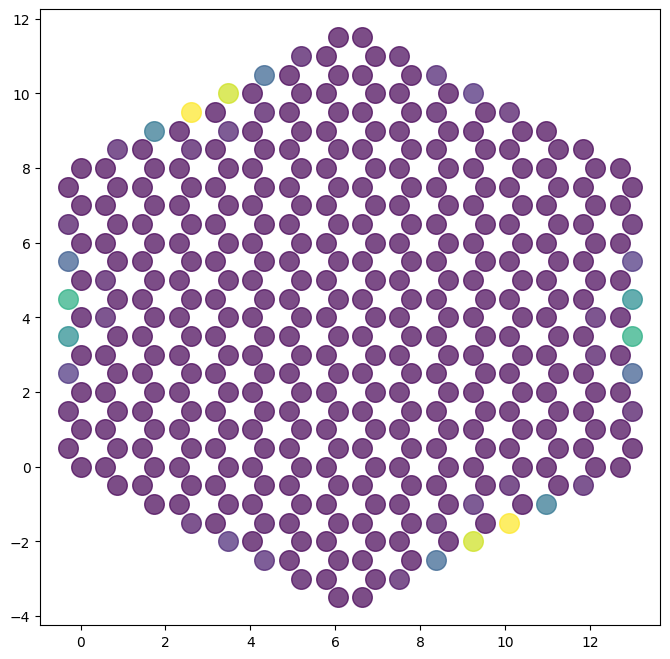

energy:  (197.6830614788709-0j)


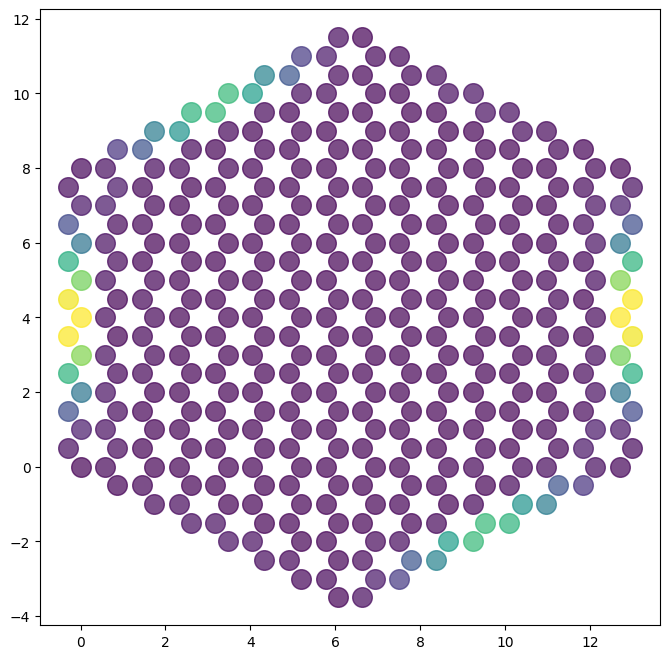

In [21]:

edge_statesA = sort_eigenvalues(np.array(edge_pops_A), vecs.T)
# edge_statesB = sort_eigenvalues(np.array(edge_pops_B), vecs.T)
from matplotlib import colormaps
cmap = colormaps['viridis']
for n in range(6):
    print("energy: ",edge_statesA[-1-n,1])
    fig, ax = plt.subplots(1,1,figsize=(8, 8))
    state = edge_statesA[-1-n,2:]
    state = np.abs(state)**2
    state = np.concatenate((state[:lattice_size]+state[lattice_size:2*lattice_size], state[2*lattice_size:3*lattice_size]+state[3*lattice_size:]))
    state = state/np.max(state)
    stateA = state[:lattice_size]
    for i in range(lattice_size):
        ax.scatter(latticeA[0,i], latticeA[1,i], color=cmap(state[i]), s=200, alpha=0.7)
        ax.scatter(latticeB[0,i], latticeB[1,i], color=cmap(state[i+lattice_size]), s=200, alpha=0.7)

    plt.show()

(9.416778141665938+0j)
192


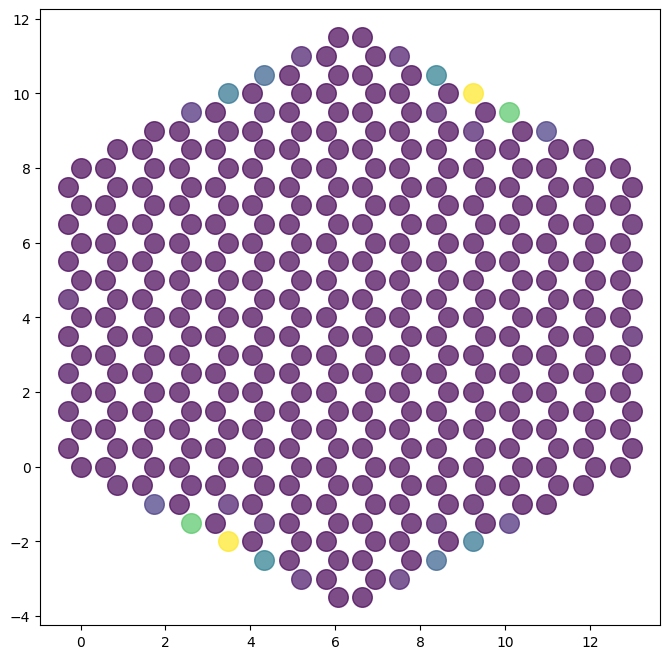

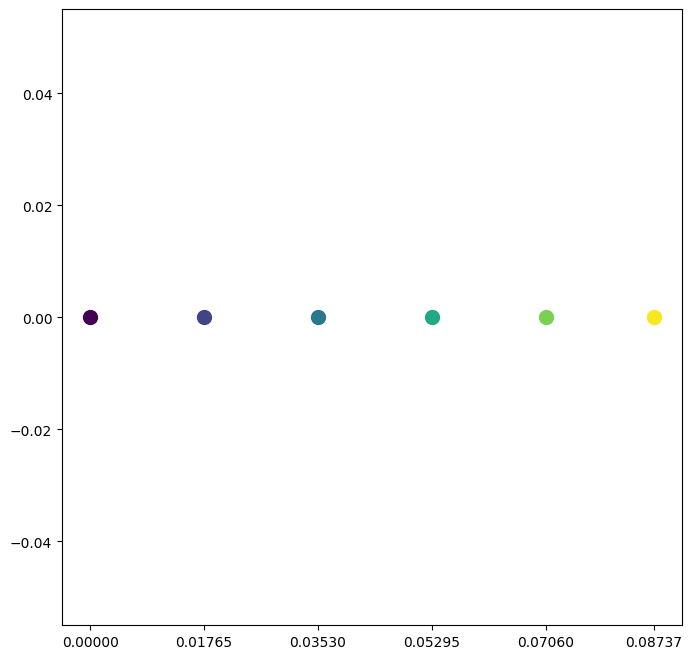

In [16]:
# print eigenstates open boundary

def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    sorted_comb = sorted(comb, key=lambda x: x[0])
    return np.array(sorted_comb)

index = np.argmin(np.abs(eig-9))
print(eig[index])
eigenvector = np.abs(vecs[:,index])**2
from matplotlib import colormaps
cmap = colormaps['viridis']
direction = 1
# eigenvector_real = np.real(eigenvector) - np.min(np.real(eigenvector))
eigenvector_real = eigenvector/ np.max(eigenvector)
# eigenvector_imag = np.imag(eigenvector) - np.min(np.imag(eigenvector))
# eigenvector_imag /= np.max(eigenvector_imag)
fig, ax = plt.subplots(1,1,figsize=(8, 8))

for i in range(count+1):
    ax.scatter(latticeA[0,i], latticeA[1,i], color=cmap(eigenvector_real[i+direction*lattice_size]), s=200, alpha=0.7)
    ax.scatter(latticeB[0,i], latticeB[1,i], color=cmap(eigenvector_real[i+direction*lattice_size+2*lattice_size]), s=200, alpha=0.7)
fig, ax = plt.subplots(1,1,figsize=(8, 8))
print(count+1)
scale =  np.array([0,0.2,0.4,0.6,0.8,0.99])
for val in scale:
    ax.scatter(val*np.max(eigenvector),0,color=cmap(val),s=100)
ax.set_xticks(np.max(eigenvector)*scale)

In [10]:
# periodic boundary condition used

def delta_R(n:int, m:int, h:int, l:int) -> float:
    """Calculate the distance between two lattice points."""
    return np.array([3/2*(m-h), np.sqrt(3)*(n+m/2-h-l/2), 0])

def interaction_AA(i: int,j: int,k: np.ndarray, interaction: Callable[[], float], interaction_onsite: Callable[[], float],latticeA,latticeB,grid_size,interaction_cut) -> float:
    R0 = latticeA[:,grid_size//2, grid_size//2 ]
    total_potential_eq = 0
    total_potential_mixed = 0
    total_potential_eq_mixed = 0
    
    # lattice A and B have same shape
    for n in range(latticeA.shape[1]):
        for m in range(latticeA.shape[2]):
           
            Del_R_vecB = latticeB[:,n,m] - R0
            if i!=j:
                total_potential_eq_mixed -= interaction(Del_R_vecB,i,j,interaction_cut)
            if n == grid_size//2 and m == grid_size//2:
                continue
            Del_R_vec = latticeA[:,n,m] - R0
            potential = interaction(Del_R_vec,i,j,interaction_cut)
            total_potential_mixed += np.exp(-1j * np.dot(Del_R_vec, k))*potential
            if i!=j:
                total_potential_eq -= potential
           
    return (total_potential_eq+total_potential_mixed+ total_potential_eq_mixed+interaction_onsite(i,j))#, test

 

def interaction_AB(i,j,k, interaction,latticeA,latticeB,grid_size,interaction_cut):
    R0 = latticeA[:,grid_size//2, grid_size//2 ]
    total_potential_mixed = 0
    for n in range(latticeB.shape[1]):
        for m in range(latticeB.shape[2]):
            
            Del_R_vec = latticeB[:,n,m] - R0
            
            # total_potential_mixed += np.exp(-1j * np.dot(Del_R_vec, k))*interaction(Del_R_vec,i,j,interaction_cut)
            total_potential_mixed += np.exp(-1j * np.dot(latticeA[:,n,m] - R0, k))*interaction(Del_R_vec,i,j,interaction_cut)
    # return 0
    return total_potential_mixed


def D_mat(k: np.ndarray, interaction: Callable[[],float], interaction_onsite: Callable[[],float],grid_size,*interaction_cut) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    latticeA = np.zeros((3,grid_size,grid_size))
    latticeB = np.zeros_like(latticeA)
    for i in range(grid_size):
        for j in range(grid_size):
            latticeA[:,i,j] = BASE_A + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
            latticeB[:,i,j] = BASE_B + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
    dmat= np.zeros((6,6), dtype=complex)
    if not interaction_cut:
        interaction_cut=[4/9*np.sqrt(3)*grid_size*10**2]
    for i in range(6):
        for j in range(6):
            if i < 3 and j < 3:
          
                dmat[i, j] = interaction_AA(i, j, k,interaction,interaction_onsite,latticeA,latticeB,grid_size,*interaction_cut)
            elif i >= 3 and j >= 3:
                dmat[i, j] = interaction_AA(i-3, j-3, k,interaction,interaction_onsite,latticeB,latticeA,grid_size,*interaction_cut)
            elif i < 3 and j >= 3:
               
                dmat[i, j] = interaction_AB(i,j-3,k,interaction,latticeA,latticeB,grid_size,*interaction_cut)
            elif i >= 3 and j < 3:
                
                dmat[i, j] = interaction_AB(i-3,j,k,interaction,latticeB,latticeA,grid_size,*interaction_cut)

    return dmat

def D_mat_alternative_grid(k: np.ndarray, interaction: Callable[[],float], interaction_onsite: Callable[[],float],grid_size,*interaction_cut) -> np.ndarray:
    """Calculate the D matrix for the given k vector."""
    # latticeA = np.zeros((3,grid_size,grid_size))
    # latticeB = np.zeros_like(latticeA)
    # BASE_B2 = 1/np.sqrt(3)*np.array([-1/2, np.sqrt(3)/2, 0])+LATTICE_VECTOR_1_ALTERNATIVE
    # BASE_A2 = LATTICE_VECTOR_1
    # for i in range(grid_size//2):
    #     latticeA[:,2*i+1,0] = BASE_A2 + i * LATTICE_VECTOR_1_ALTERNATIVE 
    #     latticeA[:,2*i,0] = BASE_A + i * LATTICE_VECTOR_1_ALTERNATIVE   

    #     latticeB[:,2*i,0] = BASE_B + i * LATTICE_VECTOR_1_ALTERNATIVE 
    #     latticeB[:,2*i+1,0] = BASE_B2 + i * LATTICE_VECTOR_1_ALTERNATIVE 
    #     for j in range(1,grid_size):
    #         latticeA[:,2*i+1,j] = latticeA[:,2*i+1,0] + j*LATTICE_VECTOR_2
    #         latticeB[:,2*i+1,j] = latticeB[:,2*i+1,0] + j*LATTICE_VECTOR_2

    #         latticeA[:,2*i,j] = latticeA[:,2*i,0] + j*LATTICE_VECTOR_2
    #         latticeB[:,2*i,j] = latticeB[:,2*i,0] + j*LATTICE_VECTOR_2
    latticeA = np.zeros((3,grid_size,grid_size+1))
    latticeB = np.zeros_like(latticeA)
    BASE_B2 = 1/np.sqrt(3)*np.array([-1/2, np.sqrt(3)/2, 0])+LATTICE_VECTOR_1_ALTERNATIVE
    BASE_A2 = LATTICE_VECTOR_1
    for i in range((grid_size+1)//2):
        latticeA[:,2*i+1,0] = BASE_A2 + i * LATTICE_VECTOR_1_ALTERNATIVE 
        latticeA[:,2*i,0] = BASE_A + i * LATTICE_VECTOR_1_ALTERNATIVE   

        latticeB[:,2*i,0] = BASE_B + i * LATTICE_VECTOR_1_ALTERNATIVE 
        latticeB[:,2*i+1,0] = BASE_B2 + i * LATTICE_VECTOR_1_ALTERNATIVE 
        for j in range(1,grid_size+1):
            latticeA[:,2*i+1,j] = latticeA[:,2*i+1,0] + j*LATTICE_VECTOR_2
            latticeB[:,2*i+1,j] = latticeB[:,2*i+1,0] + j*LATTICE_VECTOR_2

            latticeA[:,2*i,j] = latticeA[:,2*i,0] + j*LATTICE_VECTOR_2
            latticeB[:,2*i,j] = latticeB[:,2*i,0] + j*LATTICE_VECTOR_2
    dmat= np.zeros((6,6), dtype=complex)
    if not interaction_cut:
        interaction_cut=[4/9*np.sqrt(3)*grid_size*10**2]
    for i in range(6):
        for j in range(6):
            if i < 3 and j < 3:
          
                dmat[i, j] = interaction_AA(i, j, k,interaction,interaction_onsite,latticeA,latticeB,grid_size,*interaction_cut)
            elif i >= 3 and j >= 3:
                dmat[i, j] = interaction_AA(i-3, j-3, k,interaction,interaction_onsite,latticeB,latticeA,grid_size,*interaction_cut)
            elif i < 3 and j >= 3:
               
                dmat[i, j] = interaction_AB(i,j-3,k,interaction,latticeA,latticeB,grid_size,*interaction_cut)
            elif i >= 3 and j < 3:
                
                dmat[i, j] = interaction_AB(i-3,j,k,interaction,latticeB,latticeA,grid_size,*interaction_cut)

    return dmat



In [7]:
from multiprocessing import Pool
from functools import partial

# def real_index(index,index_range,index_number,base):
#         real = []
        
#         for i in range(index_number-1):
#             if type(index_range[i]) is list:
#                 if not isinstance(index_range[i][0], int):
#                     raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
#                 projected_range = index_range[i][1] - index_range[i][0]
#             else:
#                 projected_range = index_range[i]
#             real.append(index//projected_range+base[i])
#             index = index-real[i]*projected_range
#         real.append(index+base[-1])
#         return real

def real_index(index,mat_range,index_number,base):
        real = np.zeros(index_number,dtype=np.int16)
        real[-1] = index%mat_range[-1]+base[-1]
        index = index//mat_range[-1]

        for i in range(1,index_number):
            real[-1-i] = index%mat_range[-1-i]+base[-1-i]
            index = index//mat_range[-1-i]
        # print(index)
        return real

def matrix_index(index,index_range,index_number):
        real = []
        
        for i in range(index_number-1):
            if type(index_range[i]) is list:
                if not isinstance(index_range[i][0], int):
                    raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
                projected_range = index_range[i][1] - index_range[i][0]
            else:
                projected_range = index_range[i]
            real.append(index//projected_range)
            index = index-real[i]*projected_range
        real.append(index)
        return real

def wrapper(function,mat_range,index_number,base,args,x):
        # print(args)
        # print(real_index(x,mat_range,index_number,base))
        return function(*real_index(x,mat_range,index_number,base),*args)

def total_range(index_range):
    """Calculate the total range based on the index range."""
    ranges = []
    bases = []
    tot_range = 1
    for i in index_range:
        if type(i) is list:
            if not isinstance(i[0], int):
                raise ValueError("Index range must be a list of integers or a list of a tuple of integers.")
            else:
                 tot_range *= i[1]-i[0]
                 ranges.append(i[1]-i[0])
                 bases.append(i[0])
        else:
            tot_range *= i
            ranges.append(i)
            bases.append(0)
    return tot_range, ranges, bases


def parallel_for(index_range,function,*args,chunk=1):
    index_number = len(index_range)
    tot_range = 1
    tot_range, virtual_range, base = total_range(index_range)
    # print("index protperties: ",tot_range, virtual_range, base)
    
    return parallelizer(tot_range,function,index_range,index_number,virtual_range,base,chunk,*args)

    

def parallelizer(i_range,function,index_range,index_number,mat_range,base,chunk,*args):
    po = Pool(28)
    if not args:
         args=[0]
    # print(type(function))
    # print(mat_range)
    result = po.imap(partial(wrapper,function,mat_range,index_number,base,args),np.arange(i_range),chunksize=chunk)
    first_val = next(result)
    try:
         shape = first_val.shape
    except:
         try:
            shape = [len(first_val)]
         except:
              shape = []
    out = np.zeros([*mat_range,*shape],dtype=type(first_val))
    # print('first value: ',first_val)
    out[*real_index(0,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = first_val
    for index, res in enumerate(result,start=1):
        # print(index,real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16)),res)
        out[*real_index(index,mat_range,index_number,np.zeros(index_number,dtype=np.int16))] = res
        # print(real_index(index,index_range,index_number),res)
    return out


def function(i,j,base):
    # j = i%2
    # i= i//2
    print("func_arg",i,j,base)
    return i+base,j+base

def additional_wrap(i,j,base):
     i+=10
     j+=10
     return function(i,j,base)
# index_range = [3,3]

parallel_for([[0,2],[-1,2]],function,chunk=1)
# real_index(np.arange(9),[3,3],2,[0,0])

func_argfunc_argfunc_argfunc_argfunc_argfunc_arg  1   0  101 1 0  00 0  1 
-10-1 0 
0 
0
0



array([[[np.int16(0), np.int16(-1)],
        [np.int16(0), np.int16(0)],
        [np.int16(0), np.int16(1)]],

       [[np.int16(1), np.int16(-1)],
        [np.int16(1), np.int16(0)],
        [np.int16(1), np.int16(1)]]], dtype=object)

In [8]:
# extended grid no PBC used but effectively implemented

def extended_grid_interactions(n,m,i, j,k,interaction,interaction_onsite,lattice,cut):
    potential = 0
    
    for h in range(n-grid_size,n+grid_size+1):
        for l in range(m-2*grid_size,m+2*grid_size+1):
            if h==n and l==m:
                continue
            # if (m-l)%2:
            #     continue
            Del_R_vec = lattice[:,h,l] - lattice[:,n,m]
            buffer = interaction(Del_R_vec,i,j,cut)
            potential += buffer*np.exp(-1j*np.dot(Del_R_vec,k))
            potential -= buffer
    return potential+interaction_onsite(i,j)

def extended_grid_mat(k,interaction,interaction_onsite,grid_size,*cut):
    lattice = np.zeros((3,3*grid_size,6*grid_size))
    for i in range(3*grid_size):
        for j in range(3*grid_size):
            lattice[:,i,2*j] = BASE_A + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
            lattice[:,i,2*j+1] = BASE_B + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
    if not cut:
        cut = [4/9*np.sqrt(3)*grid_size]
    matrix = np.zeros((3,3),dtype=complex)
    for i in range(3):
        for j in range(3):
            for n in range(grid_size,2*grid_size):
                    for m in range(2*grid_size,4*grid_size):
                        matrix[i,j] += extended_grid_interactions(n,m,i,j,k,interaction,interaction_onsite,lattice,*cut)
    return matrix/grid_size**2/2

def extended_grid_interactions_cylindric(n,m,i, j,k,interaction,interaction_onsite,lattice,cut):
    potential = 0
    
    for h in range(2*grid_size,4*grid_size):
        for l in range(h-2*grid_size,h+2*grid_size):
            if m==n and l==h:
                potential += interaction_onsite(i,j)
                continue
            # if (m-l)%2:
            #     continue
            Del_R_vec = lattice[:,m,h] - lattice[:,n,l]
            buffer = interaction(Del_R_vec,i,j,cut)
            potential += buffer*np.exp(-1j*np.dot(Del_R_vec,k))
            potential -= buffer
    return potential

def extended_grid_mat_cylinder(k,interaction,interaction_onsite,grid_size,*cut):

    lattice = np.zeros((3,grid_size,6*grid_size))
    for i in range(grid_size):
        for j in range(3*grid_size):
            lattice[:,i,2*j] = BASE_A + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
            lattice[:,i,2*j+1] = BASE_B + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
    if not cut:
        cut = [4/9*np.sqrt(3)*grid_size]
    matrix = np.zeros((3*grid_size,3*grid_size),dtype=complex)
    for i in range(3):
        for j in range(3):
            for n in range(grid_size):
                    for m in range(grid_size):
                        matrix[n+i*grid_size,m+j*grid_size] += extended_grid_interactions_cylindric(n,m,i,j,k,interaction,interaction_onsite,lattice,*cut)
    return matrix/grid_size/2


def extended_same_grid_interactions(n,m,i, j,k,interaction,interaction_onsite,latticeA,latticeB,grid_size,cut):
    potential = 0
    # print(cut)
    for h in range(n-grid_size,n+grid_size+1):
        for l in range(m-grid_size,m+grid_size+1):
            Del_R_vecAB = latticeB[:,h,l] - latticeA[:,n,m]
            potential -= interaction(Del_R_vecAB,i,j,cut)
            if h==n and l==m:
                continue
            # if (m-l)%2:
            #     continue
            Del_R_vec = latticeA[:,h,l] - latticeA[:,n,m]
            buffer = interaction(Del_R_vec,i,j,cut)
            potential += buffer*np.exp(-1j*np.dot(Del_R_vec,k))
            potential -= buffer
    return potential+interaction_onsite(i,j)


def extended_mixed_grid_interactions(n,m,i, j,k,interaction,interaction_onsite,latticeA, latticeB, grid_size, cut):
    potential = 0
    
    for h in range(n-grid_size,n+grid_size+1):
        for l in range(m-grid_size,m+grid_size+1):    
            # if (m-l)%2:
            #     continue
            Del_R_vec = latticeB[:,h,l] - latticeA[:,n,m]
            buffer = interaction(Del_R_vec,i,j,cut)
            potential += buffer*np.exp(-1j*np.dot(Del_R_vec,k))
    return potential


def extended_ABgrid_mat(k,interaction,interaction_onsite,grid_size,*cut):

    latticeA = np.zeros((3,3*grid_size,3*grid_size))
    latticeB = np.zeros_like(latticeA)
    for i in range(3*grid_size):
        for j in range(3*grid_size):
            latticeA[:,i,j] = BASE_A + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
            latticeB[:,i,j] = BASE_B + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
    if not cut:
        cut = [4/9*np.sqrt(3)*grid_size]
    matrix = np.zeros((6,6),dtype=complex)
    # n, m = 3*grid_size//2, 3*grid_size//2

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[0]):
            if i < 3 and j < 3:
                for n in range(grid_size,2*grid_size):
                    for m in range(grid_size,2*grid_size):
                        matrix[i,j] += extended_same_grid_interactions(n,m,i,j,k,interaction,interaction_onsite,latticeA,latticeB,grid_size,*cut)
            elif i >= 3 and j >= 3:
                for n in range(grid_size,2*grid_size):
                    for m in range(grid_size,2*grid_size):
                        matrix[i,j] += extended_same_grid_interactions(n,m,i-3,j-3,k,interaction,interaction_onsite,latticeB,latticeA,grid_size,*cut)
            elif i < 3 and j >= 3:
                for n in range(grid_size,2*grid_size):
                    for m in range(grid_size,2*grid_size):
                        matrix[i,j] += extended_mixed_grid_interactions(n,m,i,j-3,k,interaction,interaction_onsite,latticeA,latticeB, grid_size,*cut)
            elif i >= 3 and j < 3:
                for n in range(grid_size,2*grid_size):
                    for m in range(grid_size,2*grid_size):
                        matrix[i,j] += extended_mixed_grid_interactions(n,m,i-3,j,k,interaction,interaction_onsite,latticeB,latticeA, grid_size,*cut)
            

    return matrix/grid_size**2

def extended_same_grid_interactions_cylindric(n,m,i, j,k,interaction,interaction_onsite,latticeA,latticeB,grid_size,cut):
    potential = 0
    for h in range(grid_size,2*grid_size):
        for l in range(h-grid_size,h+grid_size):
            
            Del_R_vecAB = latticeB[:,m,l] - latticeA[:,n,h]
            potential -= interaction(Del_R_vecAB,i,j,cut)
            if m==n and l==h:
                potential += interaction_onsite(i,j)
                continue
            # if (m-l)%2:
            #     continue
            
    
            Del_R_vec = latticeA[:,m,l] - latticeA[:,n,h]
            buffer = interaction(Del_R_vec,i,j,cut)
            potential += buffer*np.exp(-1j*np.dot(Del_R_vec,k))
            potential -= buffer
            
    return potential

   


def extended_mixed_grid_interactions_cylindric(n,m,i, j,k,interaction,interaction_onsite,latticeA, latticeB, grid_size, cut):
    potential = 0
    
    for h in range(grid_size,2*grid_size):
        for l in range(h-grid_size,h+grid_size):
            # if (m-l)%2:
            #     continue
            Del_R_vec = latticeB[:,m,l] - latticeA[:,n,h]
            
            potential += interaction(Del_R_vec,i,j,cut)*np.exp(-1j*np.dot(Del_R_vec,k))
    return potential



def extended_ABgrid_mat_cylindric(k,interaction,interaction_onsite,grid_size,*cut):
    latticeA = np.zeros((3,grid_size,3*grid_size))
    latticeB = np.zeros_like(latticeA)
    for i in range(grid_size):
        for j in range(3*grid_size):
            latticeA[:,i,j] = BASE_A + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
            latticeB[:,i,j] = BASE_B + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
    if not cut:
        cut = [4/9*np.sqrt(3)*grid_size]
    matrix = np.zeros((6*grid_size,6*grid_size),dtype=complex)
    # n, m = 3*grid_size//2, 3*grid_size//2

    for i in range(6):
        for j in range(6):
            if i < 3 and j < 3:
                for n in range(grid_size):
                    for m in range(grid_size):
                        matrix[i*grid_size+n,j*grid_size+m] = extended_same_grid_interactions_cylindric(n,m,i,j,k,interaction,interaction_onsite,latticeA,latticeB,grid_size,*cut)
            elif i >= 3 and j >= 3:
                for n in range(grid_size):
                    for m in range(grid_size):
                        matrix[i*grid_size+n,j*grid_size+m] = extended_same_grid_interactions_cylindric(n,m,i-3,j-3,k,interaction,interaction_onsite,latticeB,latticeA,grid_size,*cut)
            elif i < 3 and j >= 3:
                for n in range(grid_size):
                    for m in range(grid_size):
                        matrix[i*grid_size+n,j*grid_size+m] = extended_mixed_grid_interactions_cylindric(n,m,i,j-3,k,interaction,interaction_onsite,latticeA,latticeB, grid_size,*cut)
            elif i >= 3 and j < 3:
                for n in range(grid_size):
                    for m in range(grid_size):
                        matrix[i*grid_size+n,j*grid_size+m] = extended_mixed_grid_interactions_cylindric(n,m,i-3,j,k,interaction,interaction_onsite,latticeB,latticeA, grid_size,*cut)
            

    return matrix/grid_size


# grid_size= 3
# lattice = np.zeros((3,3*grid_size,6*grid_size))
# for i in range(3*grid_size):
#     for j in range(3*grid_size):
#         lattice[:,i,2*j] = BASE_A + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2
#         lattice[:,i,2*j+1] = BASE_B + i * LATTICE_VECTOR_1 + j*LATTICE_VECTOR_2

# plt.figure(figsize=(8,8))
# for i in range(lattice.shape[1]):
#     for j in range(lattice.shape[2]):
#         # plt.scatter(lattice[0,i,j],lattice[1,i,j],color='indianred')
#         # for n in range(grid_size+1):
#         #     for m in range(grid_size):
#         #         if np.linalg.norm(lattice[:,i-grid_size,j-grid_size] - latticeB[:,n,m]) < 0.01 or np.linalg.norm(lattice[:,i-grid_size,j-grid_size] - latticeA[:,n%grid_size,m]) < 0.01:
#         #             plt.scatter(lattice[0,i,j],lattice[1,i,j],color='0')
#         #             break
#         if i >= grid_size and j >=2*grid_size and i < 2*grid_size and j < 4* grid_size:
#             plt.scatter(lattice[0,i,j],lattice[1,i,j],color='indianred')
#         elif i > grid_size and j ==2*grid_size-1 and i <= 2*grid_size:
#             plt.scatter(lattice[0,i,j],lattice[1,i,j],color='green')
#         elif i >= grid_size-1 and j >=2*grid_size-1 and i < 2*grid_size+1 and j < 4* grid_size+1:
#             plt.scatter(lattice[0,i,j],lattice[1,i,j],color='blue')
#         # else:
#         #     plt.scatter(lattice[0,i,j],lattice[1,i,j],color='0')
# plt.show()
# k = np.zeros(3)
# dmat2 = extended_grid_mat(k,bare_interaction,grid_size)#D_mat(k,bare_interaction,lambda x, y : 0)

# k = k_course(t[0])
# k = np.zeros(3)
# dmat = D_mat(k,bare_interaction_coulomb,no_onsite_interaction,350)
# # dmat2 = extended_ABgrid_mat(k,bare_interaction_coulomb,no_onsite_interaction,11)#D_mat(k,bare_interaction,lambda x, y : 0)
# # dmat3 = D_mat_nn(k)
# # dmat1 = np.zeros((3,3),dtype=complex)
# # dmat5 = np.zeros((3,3),dtype=complex)
# # for h in range(3):
# #     for l in range(3):
# #         dmat1[h,l] = dmat[h,l]+ dmat[h+3,l] +dmat[h,l+3] + dmat[h+3,l+3]
# #         dmat5[h,l] = dmat3[h,l]+ dmat3[h+3,l] +dmat3[h,l+3] + dmat3[h+3,l+3]
  

# dmat#, dmat2/dmat2[0,0]*dmat[0,0] 
# np.max(dmat)#, np.max(dmat2/dmat2[0,0]*dmat[0,0])

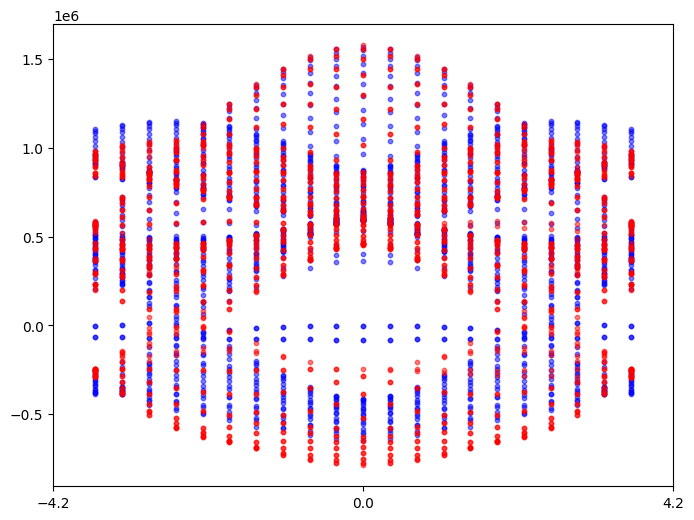

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
k2 = 2*np.pi/3*np.array([-1,np.sqrt(3),0])   
k1 = 4*np.pi/3*np.array([1,0,0])
grid_size = 20
k_size = grid_size
def sort_eigenvalues(eigenvalues: np.ndarray,eigenvectors: np.ndarray) -> np.ndarray:
    """Sort eigenvalues in ascending order."""
    eigenvectors *= np.conjugate(eigenvectors[0, :])/np.absolute(eigenvectors[0,:])#np.array([np.absolute(eigenvectors[0,i]) for i in range(eigenvectors.shape[1])]) # Normalize the eigenvectors
    comb = np.column_stack((eigenvalues.T, eigenvectors.T))
    # return comb
    sorted_comb = sorted(comb, key=lambda x: x[0])
    return np.array(sorted_comb)
kx = np.arange(-(k_size//2),k_size//2+1)/k_size*np.linalg.norm(REZI_2)#/k_size * k1[0]
def wrap_66_simple(i,k_size,real_grid_size):
    k = i/k_size * np.array([0,1,0])*2*np.pi #REZI_2 #
    # dmat = cylindric_Dmat(k,bare_interaction_coulomb,bare_interaction_coulomb_onsite,real_grid_size)
    dmat = cylindric_Dmat(k,bare_interaction,no_onsite_interaction,real_grid_size)
    # dmat1 = np.zeros((3*grid_size,3*grid_size),dtype=complex)
    # for h in range(dmat1.shape[0]):
    #     for l in range(dmat1.shape[1]):
    #         dmat1[h,l] = dmat[h,l]+ dmat[h+3*grid_size,l] +dmat[h,l+3*grid_size] + dmat[h+3*grid_size,l+3*grid_size]
    eigvals, eigvecs = np.linalg.eig(dmat)
    # return sorted(np.real(eigvals[:]) )
    # print(np.sum(np.absolute(eigvecs)**2,axis=0))
    return sort_eigenvalues(eigvals, eigvecs)

eigenvecs2 = parallel_for([[-(k_size//2),k_size//2+1]],wrap_66_simple,k_size,grid_size).astype(np.complex64)

def wrap_simple(i,j,grid_sizek,real_grid_size):
    # i -= grid_sizek//2
    # j -= grid_sizek//2
    # print(real_grid_size,k_size)
    k = i/grid_sizek * REZI_1 + j/grid_sizek * REZI_2
    # dmat = D_mat_alternative_grid(k,bare_interaction_coulomb,bare_interaction_coulomb_onsite,real_grid_size)
    dmat = D_mat_alternative_grid(k,bare_interaction,no_onsite_interaction,real_grid_size)
    # dmat = D_mat(k,bare_interaction_coulomb,bare_interaction_coulomb_onsite,grid_size)
    eigvals, eigvecs = np.linalg.eig(dmat)
    return sort_eigenvalues(eigvals, eigvecs)
    # return sorted(np.real(eigvals[:]))

eigenvals = parallel_for([[-(k_size//2),k_size//2+1],[-(k_size//2),k_size//2+1]],wrap_simple,k_size,grid_size).astype(np.complex64)

# print(eigenvals.shape)
for j in range(2*grid_size,6*grid_size):
    # ax.scatter(kx, eigenvals[ :, j], color='blue', s=10, alpha=0.5)
    ax.scatter(kx, eigenvecs2[ :, j,0], color='blue', s=10, alpha=0.5)

# kx = np.zeros((k_size+1,k_size+1))
# for i in range(-(k_size//2),k_size//2+1):
#     for j in range(-(k_size//2),k_size//2+1):
       
#         k = i/k_size * REZI_1 + j/k_size * REZI_2
#         kx[i+k_size//2,j+k_size//2] = k[0]

for h in range(2,6):
    for j in range(k_size):
        ax.scatter(kx, eigenvals[ j,:,h,0], color='red', s=10, alpha=0.5)
        # ax.scatter(kx, eigenvals3[ j,:,h], color='blue', s=10, alpha=0.5)

ax.set_xticks([-4.2,0,4.2])

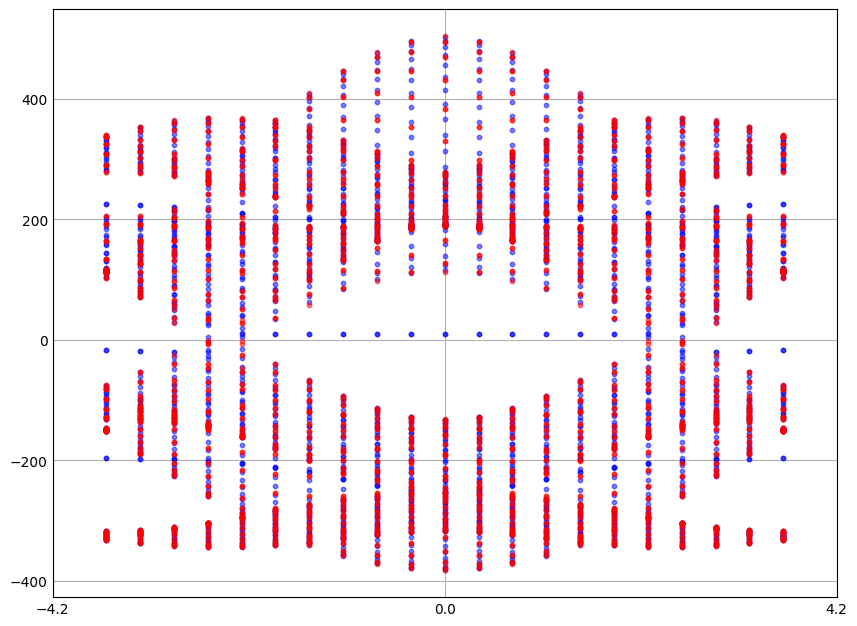

In [19]:
fig, ax = plt.subplots(1,1,figsize=(8, 6))
kx = np.arange(-(k_size//2),k_size//2+1)/k_size*np.linalg.norm(REZI_2)#/k_size * k1[0]
band_start, band_stop = (0,6)
for j in range(band_start*grid_size,band_stop*grid_size):
    # ax.scatter(kx, eigenvals[ :, j], color='blue', s=10, alpha=0.5)
    ax.scatter(kx, eigenvecs2[ :, j,0], color='blue', s=10, alpha=0.5)


for h in range(band_start,band_stop):
    for j in range(k_size):
        ax.scatter(kx, eigenvals[ j,:,h,0], color='red', s=10, alpha=0.5)
        # ax.scatter(kx, eigenvals3[ j,:,h], color='blue', s=10, alpha=0.5)

ax.set_xticks([-4.2,0,4.2])
plt.show()

In [10]:
import os
os.makedirs('dipole_edge_state',exist_ok=True)
np.save('dipole_edge_state/periodic5.npy',eigenvals)
np.save('dipole_edge_state/cylindric5.npy',eigenvecs2)

In [11]:
eigenvecs2.shape

(21, 120, 121)

In [1]:
fig, ax = plt.subplots(figsize=(8, 6))
for j in range(0*grid_size,6*grid_size):
    # ax.scatter(kx, eigenvals[ :, j], color='blue', s=10, alpha=0.5)
    ax.scatter(kx, eigenvecs2[ :, j,0], color='blue', s=10, alpha=0.5)


for h in range(6):
    for j in range(k_size):
        ax.scatter(kx, eigenvals[ j,:,h,0], color='red', s=10, alpha=0.5)
        # ax.scatter(kx, eigenvals3[ j,:,h], color='blue', s=10, alpha=0.5)

ax.set_xticks([-4.2,0,4.2])

NameError: name 'plt' is not defined

(-17.502861-1.711507e-15j)
(-18.192066+1.57524e-05j)
(-20.191603-3.8984686e-05j)
(-3.589764-0.00013953698j)
(4.924023-6.6944986e-06j)
(9.663071-7.440848e-06j)
(8.86688+1.1141519e-06j)
(8.806939+3.3837557e-07j)
(9.279155-2.4581144e-07j)
(9.860111+8.09087e-08j)
(10.117329+0j)
(9.860111-8.09087e-08j)
(9.279155+2.4581144e-07j)
(8.806939-3.3837557e-07j)
(8.86688-1.1141519e-06j)
(9.663071+7.440848e-06j)
(4.924023+6.6944986e-06j)
(-3.589764+0.00013953698j)
(-20.191603+3.8984686e-05j)
(-18.192066-1.57524e-05j)
(-17.502861+1.711507e-15j)


/tmp/ipykernel_6560/4089341814.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8,6))


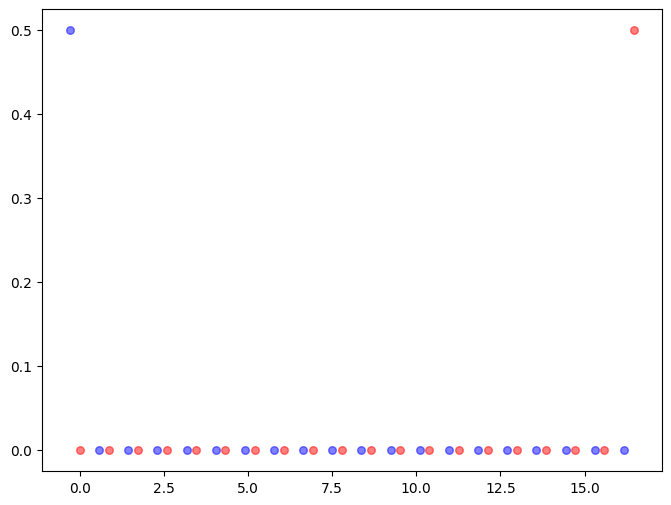

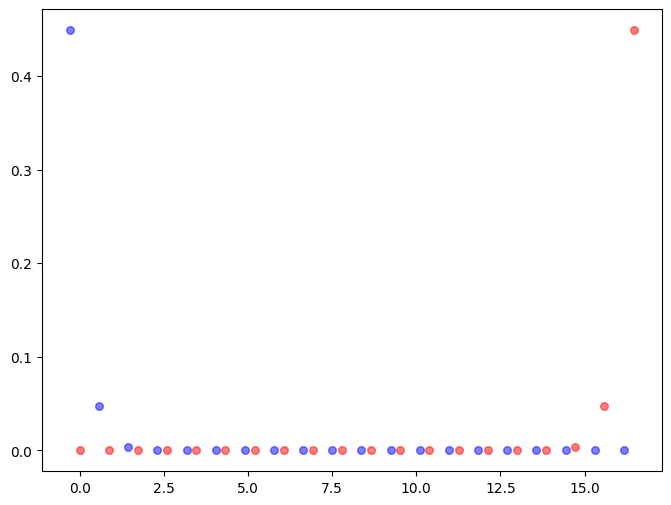

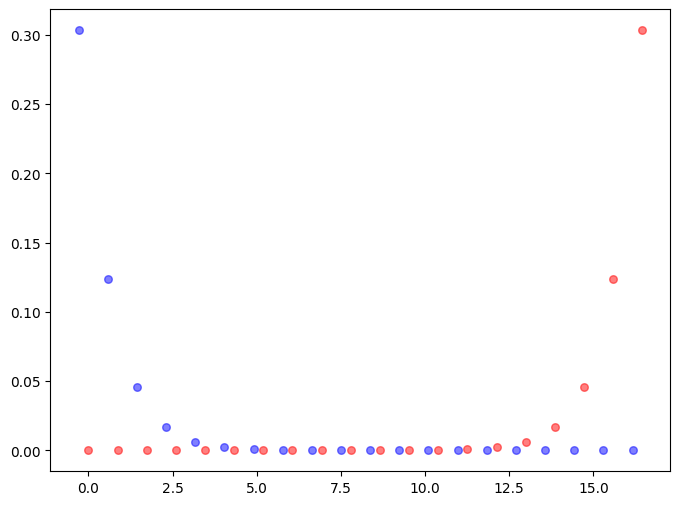

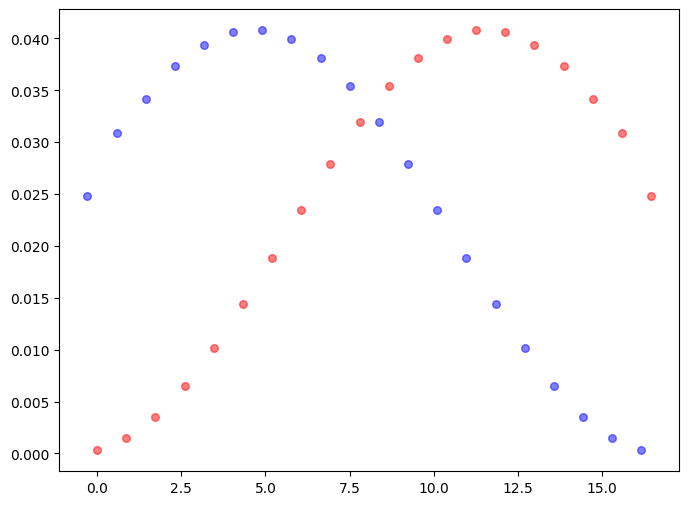

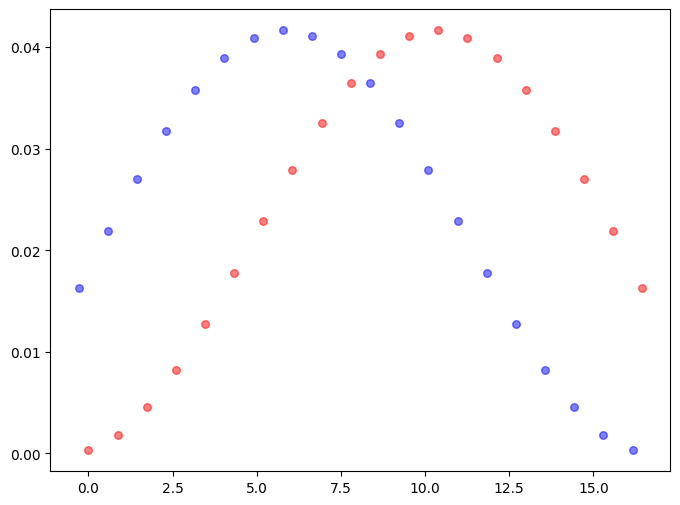

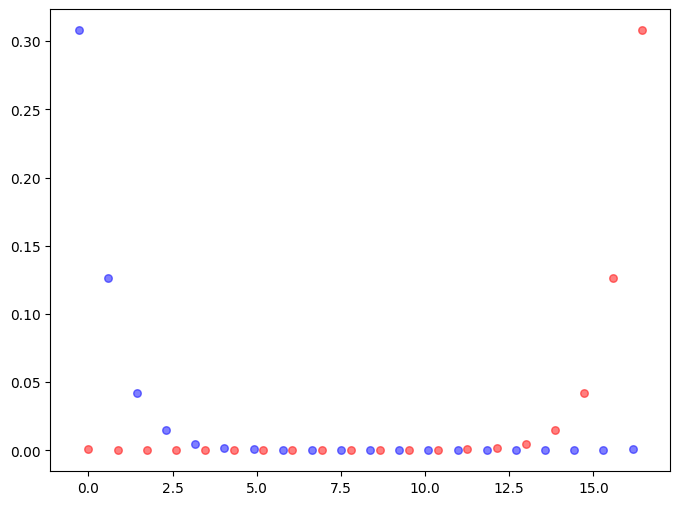

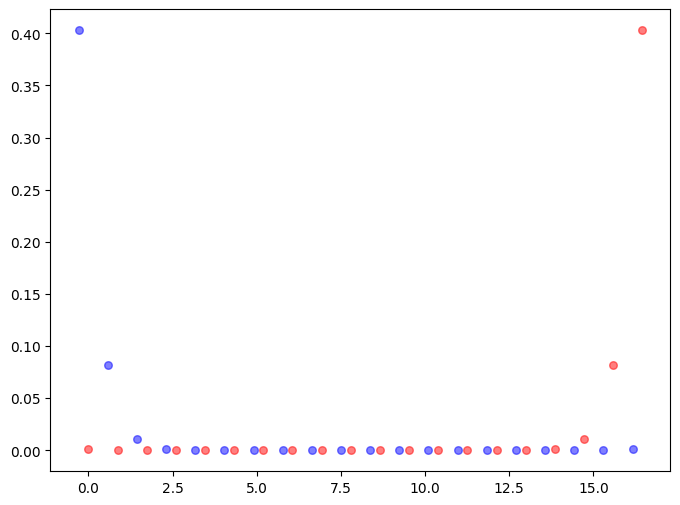

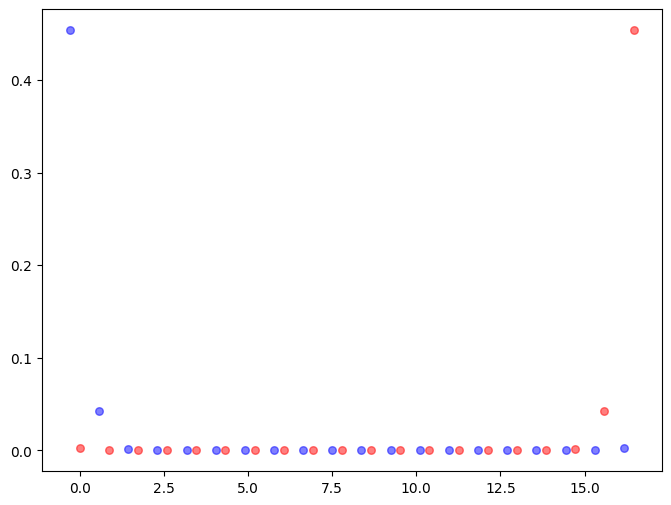

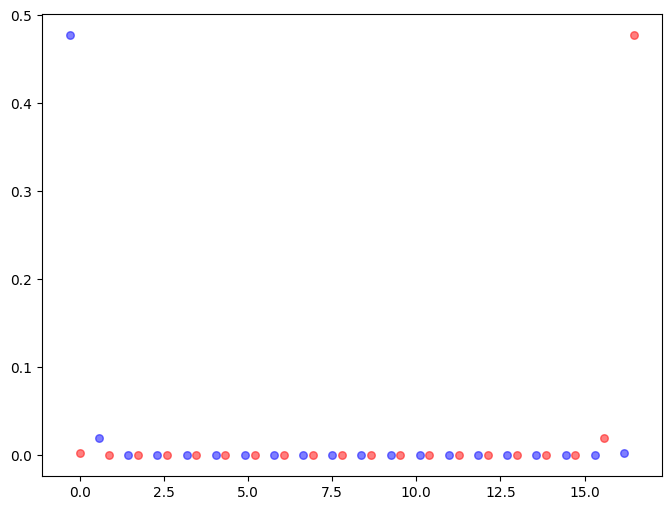

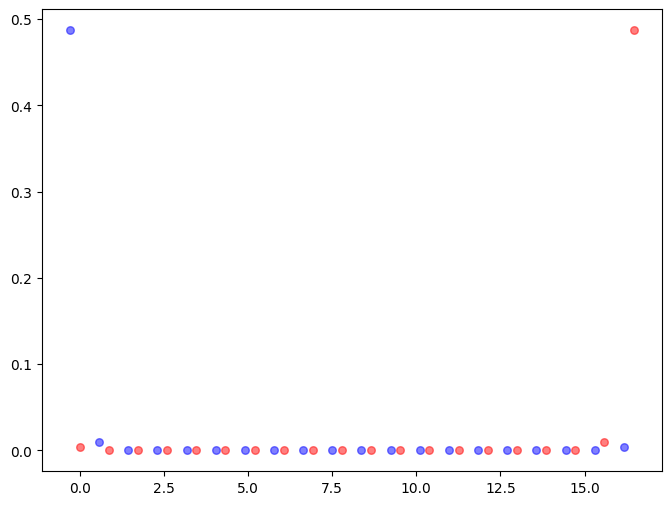

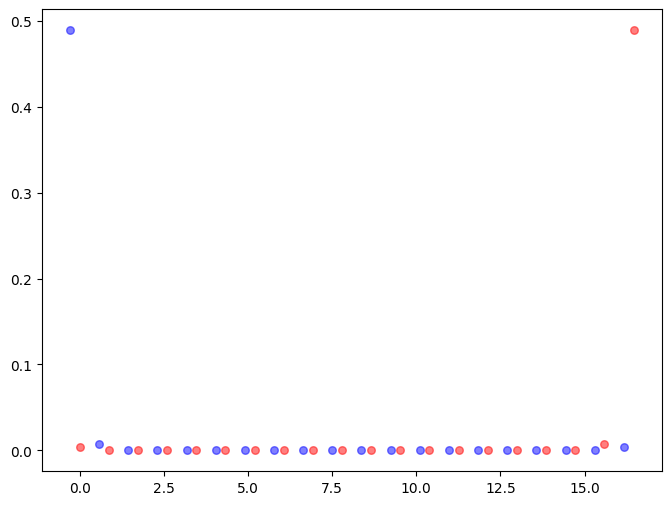

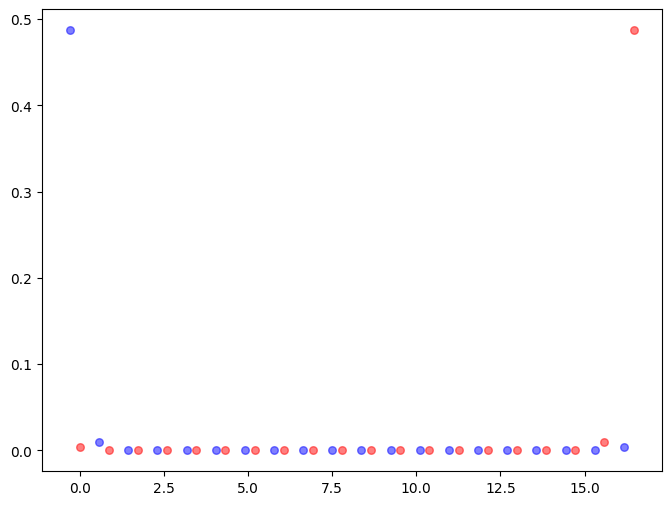

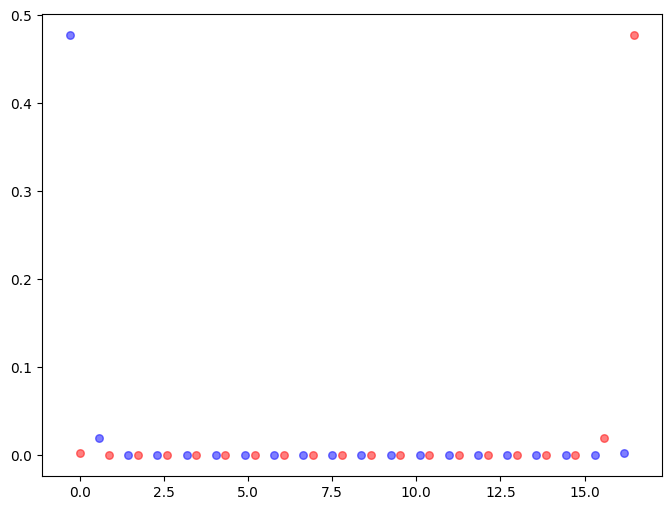

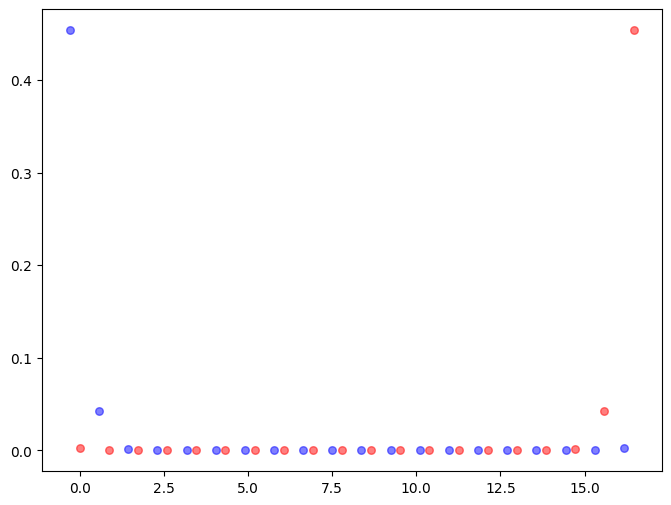

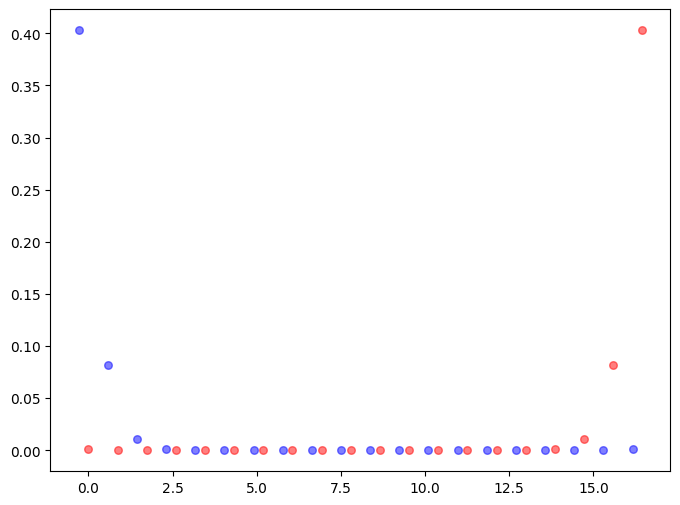

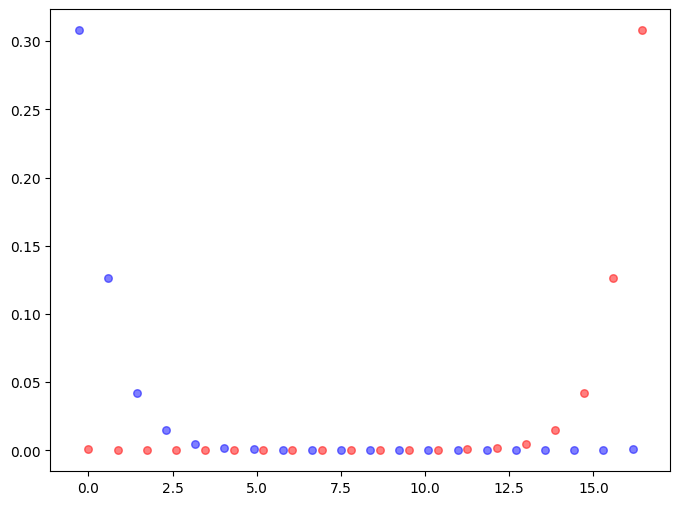

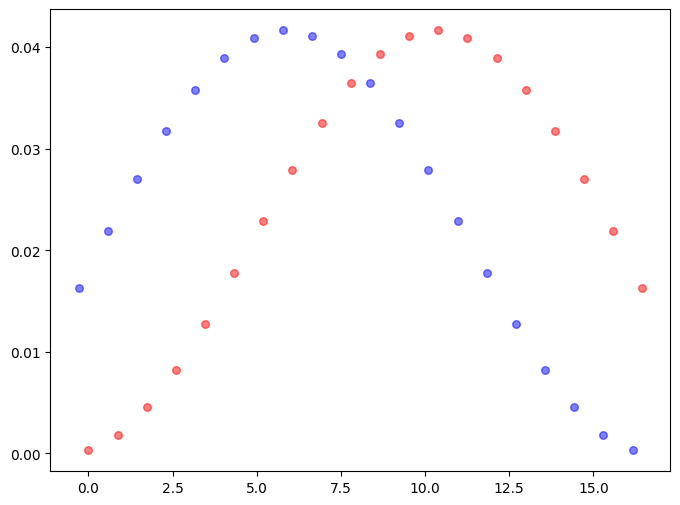

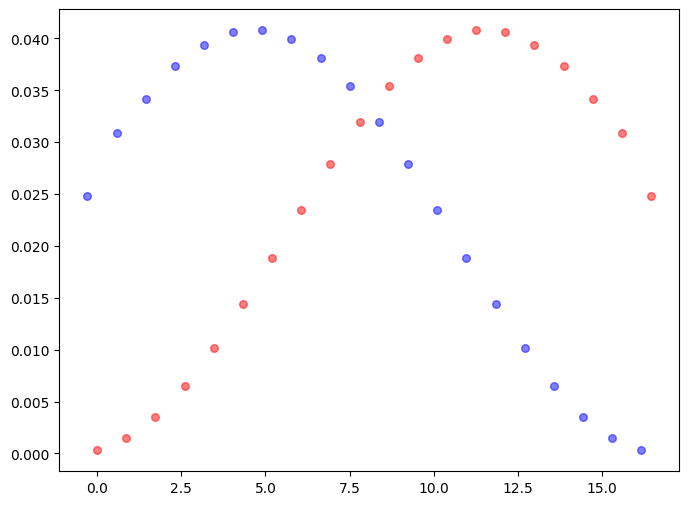

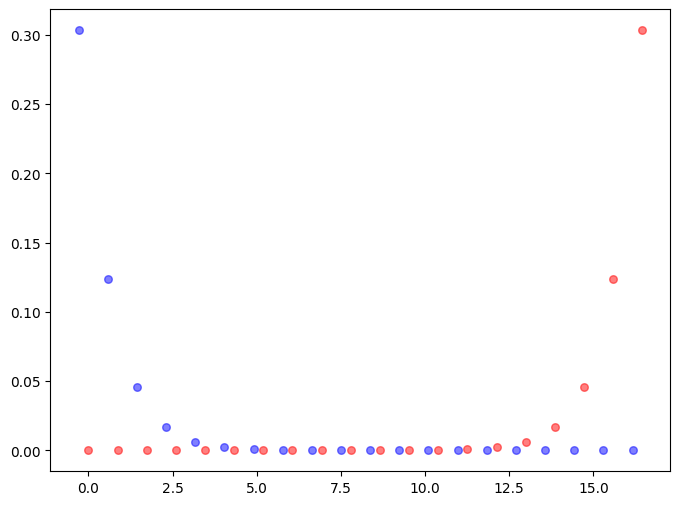

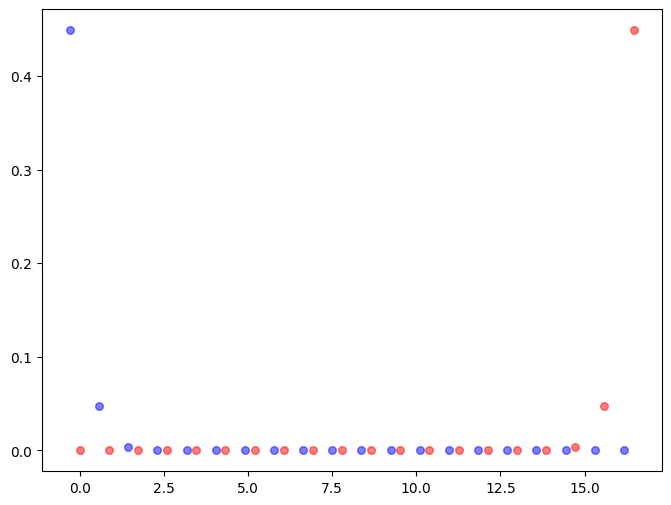

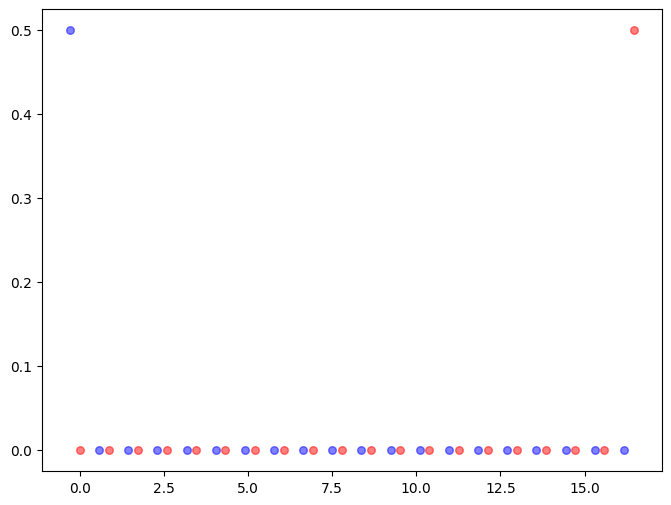

In [53]:
# print eigenstates cylindric boundiary conditions
for i in range(len(kx)):
    fig, ax = plt.subplots(figsize=(8,6))
    index = np.argmin(np.abs(np.real(eigenvecs2[i,:,0])))
    print(eigenvecs2[i,index,0])
    vecA = np.abs(eigenvecs2[i,index,1:grid_size+1])**2+np.abs(eigenvecs2[i,index,grid_size+1:2*grid_size+1])**2+np.abs(eigenvecs2[i,index,2*grid_size+1:3*grid_size+1])**2
    vecB = np.abs(eigenvecs2[i,index,3*grid_size+1:4*grid_size+1])**2+np.abs(eigenvecs2[i,index,4*grid_size+1:5*grid_size+1])**2+np.abs(eigenvecs2[i,index,5*grid_size+1:6*grid_size+1])**2
    
    ax.scatter(np.arange(grid_size//2)*np.sqrt(3),vecA[::2],color='red',s=30,alpha=0.5)
    ax.scatter(np.arange(grid_size//2)*np.sqrt(3)+1/2*np.sqrt(3),vecA[1::2],color='red',s=30,alpha=0.5)
    ax.scatter(np.arange(grid_size//2)*np.sqrt(3)-1/2/np.sqrt(3),vecB[::2],color='blue',s=30,alpha=0.5)
    ax.scatter(np.arange(grid_size//2)*np.sqrt(3)+1/np.sqrt(3),vecB[1::2],color='blue',s=30,alpha=0.5)

(-0.018050399-4.8198802e-17j)
(-0.01805092+1.727686e-18j)


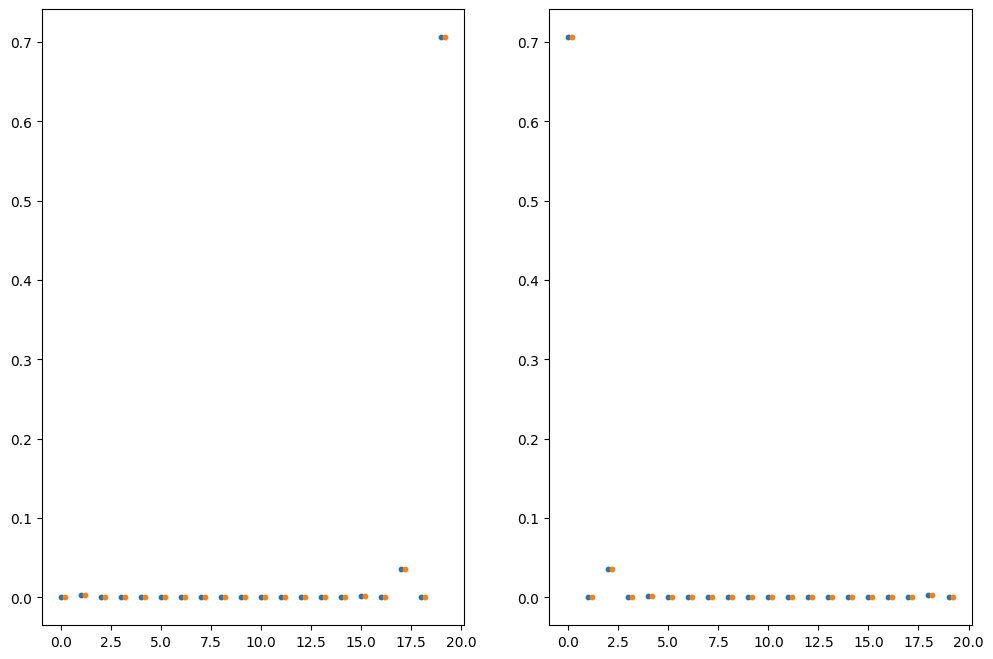

(-0.018578796+1.1162592e-06j)
(-0.018579133+1.1155133e-06j)


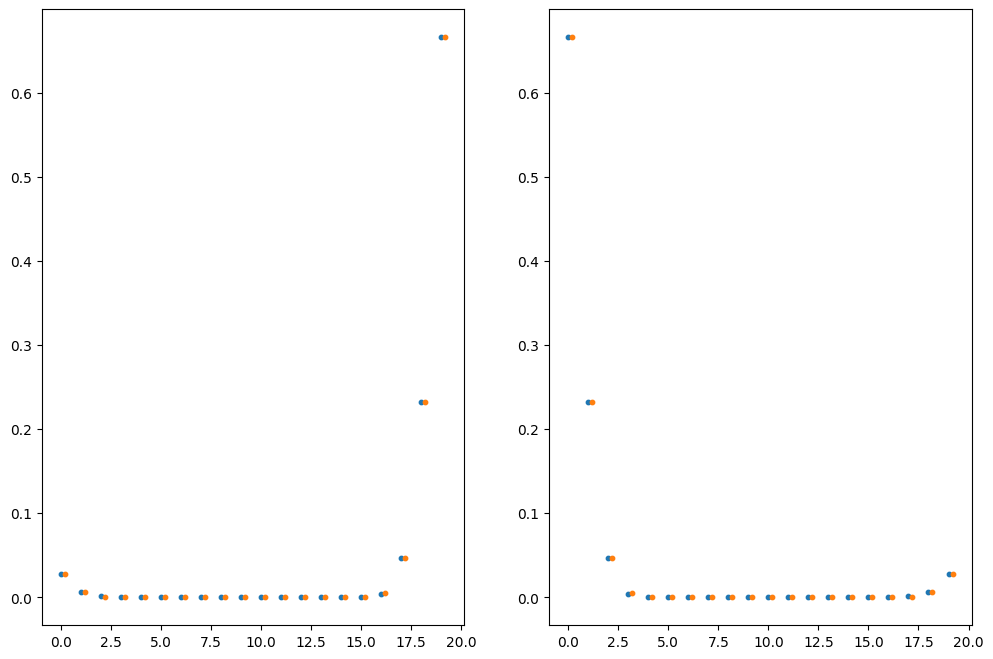

(0.83120805-8.547127e-07j)
(0.85218513+5.889748e-08j)


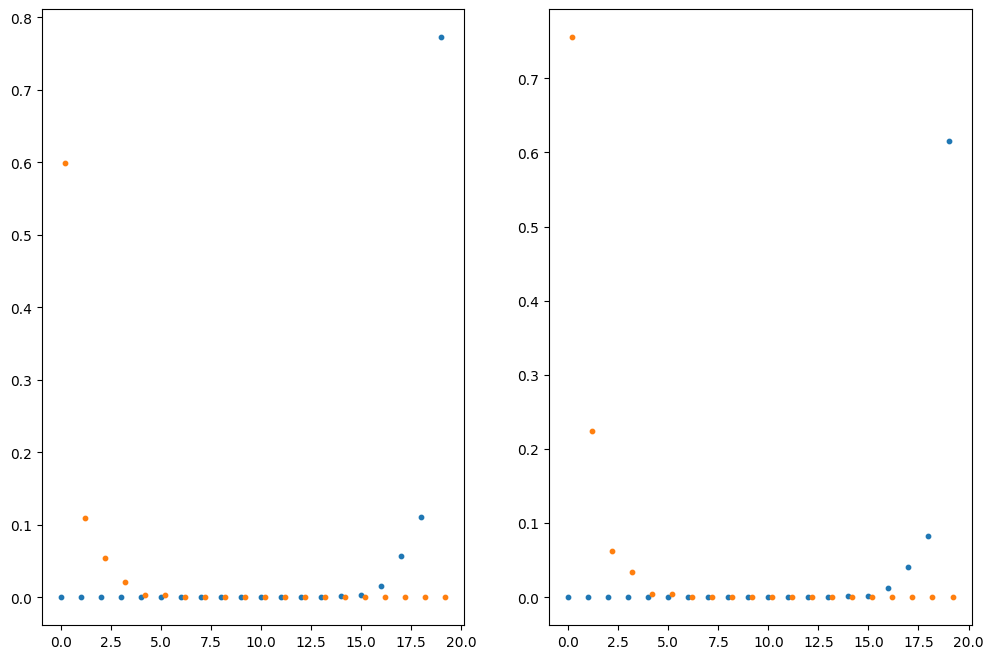

(0.8286294+8.1947076e-07j)
(0.86153024-3.6712703e-07j)


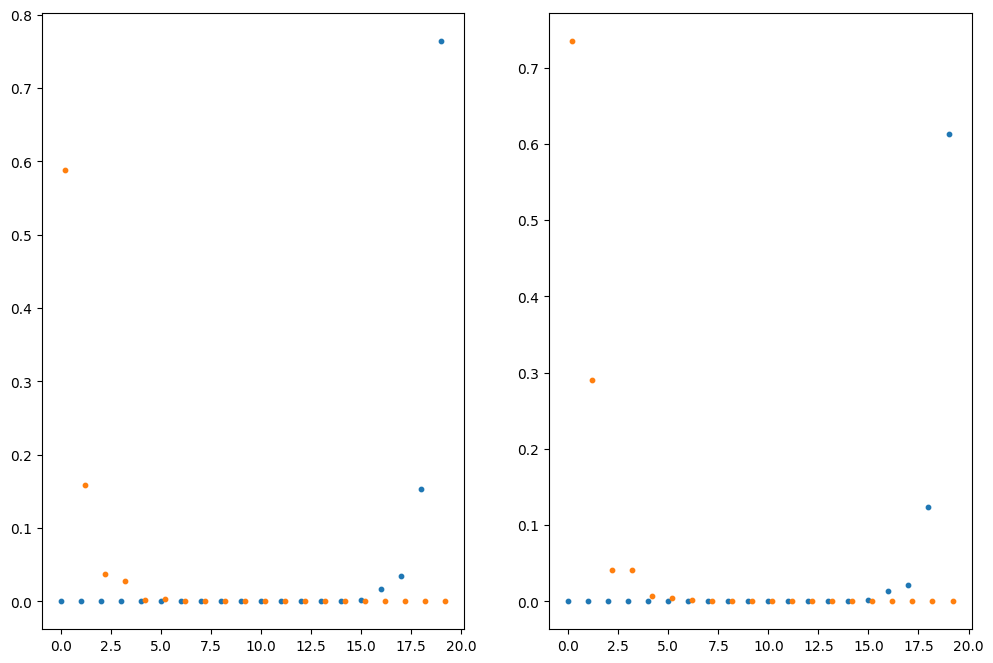

(0.8259254-1.3735007e-06j)
(0.87253195-5.542528e-07j)


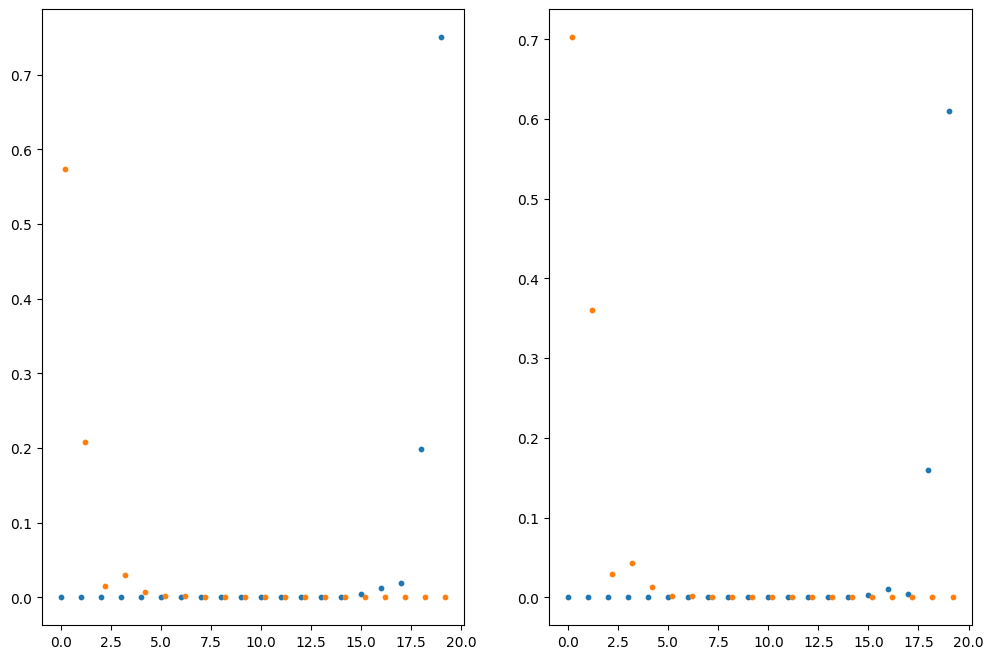

(0.8221479+9.577708e-07j)
(0.88492435-6.2450283e-07j)


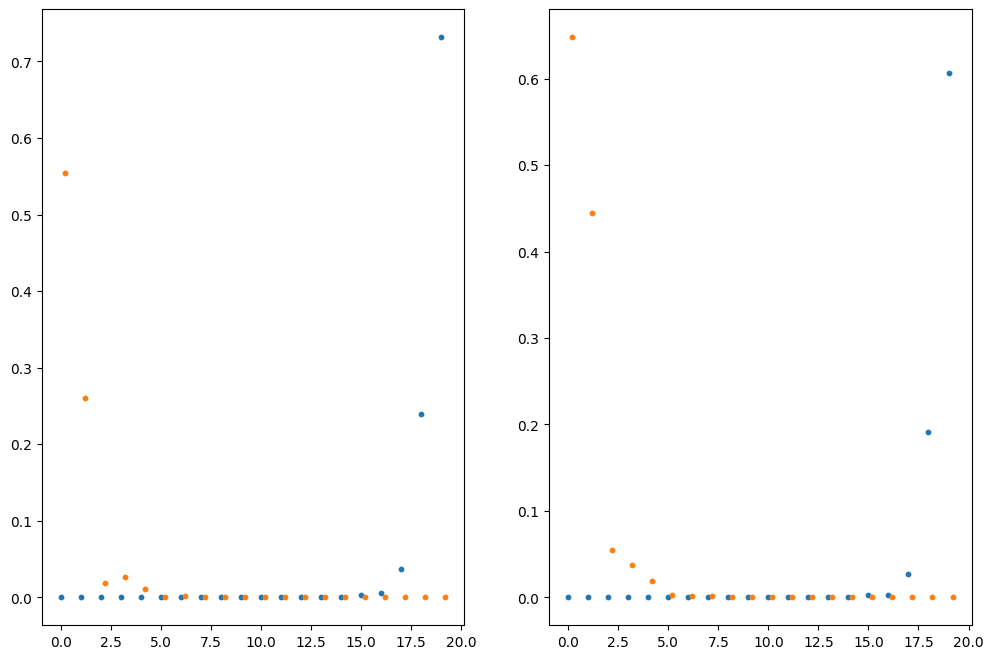

(0.89792323-1.0483384e-06j)
(0.8162703-1.7192509e-06j)


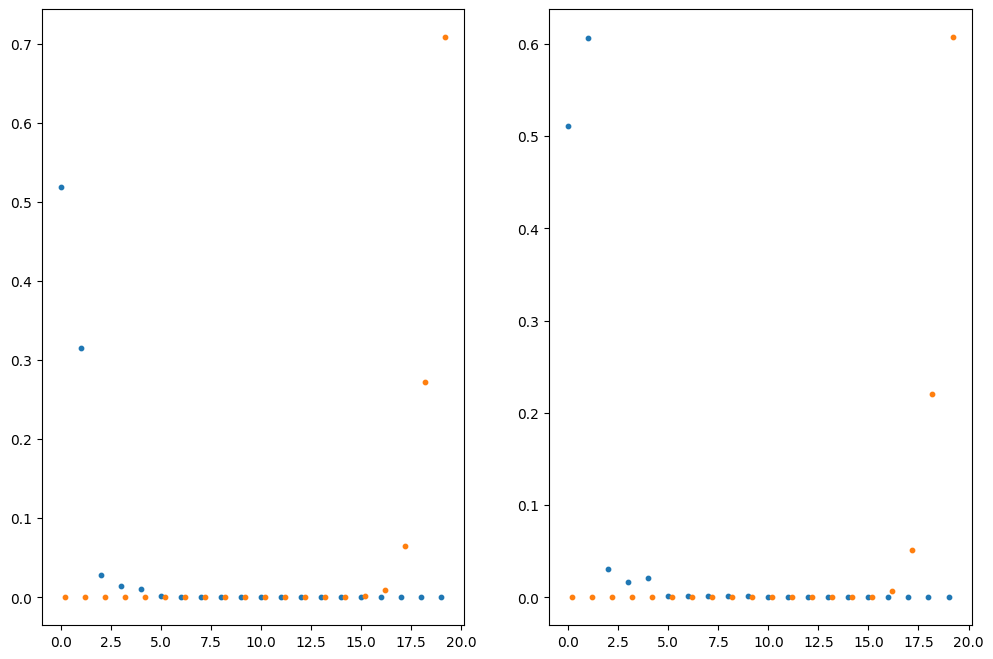

(0.80714446+2.1951486e-07j)
(-0.10528614-7.247723e-08j)


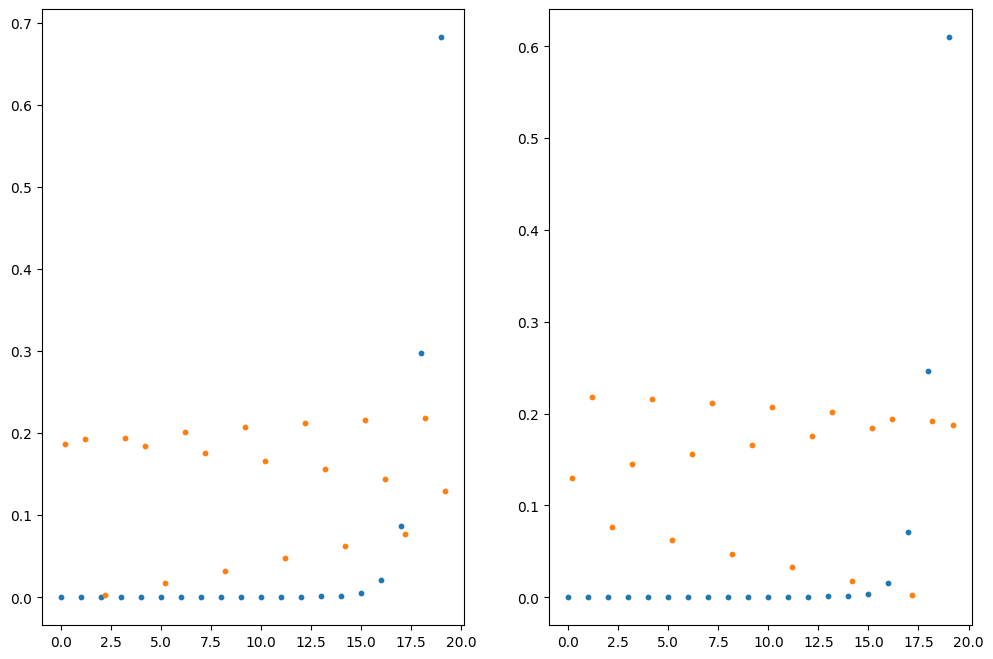

(0.7942565-1.243508e-06j)
(0.9303154+3.258695e-06j)


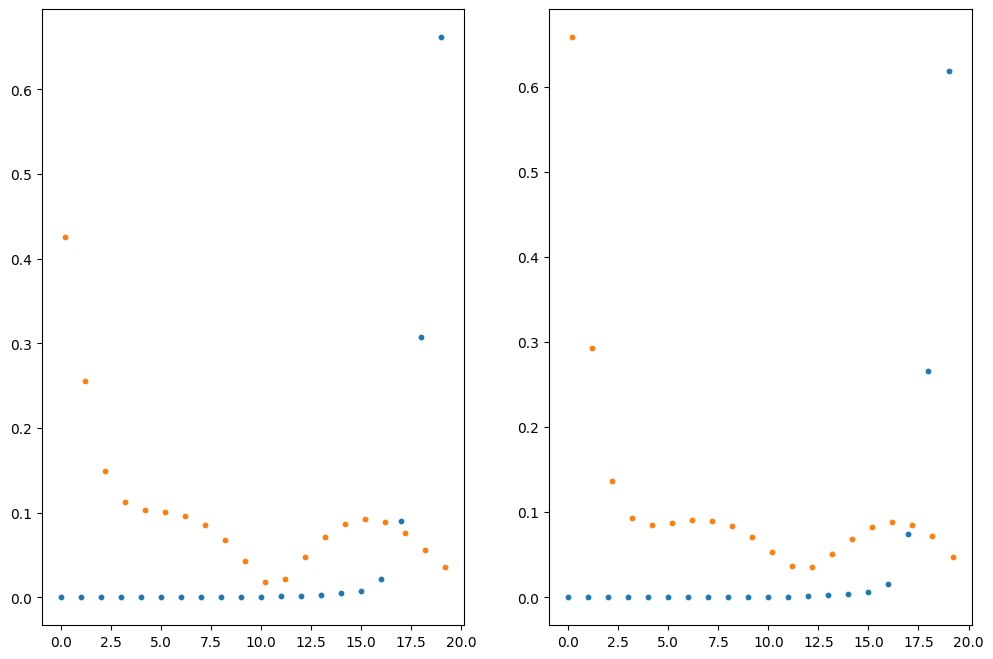

(0.77868015-2.2296106e-06j)
(0.9444326+5.16172e-07j)


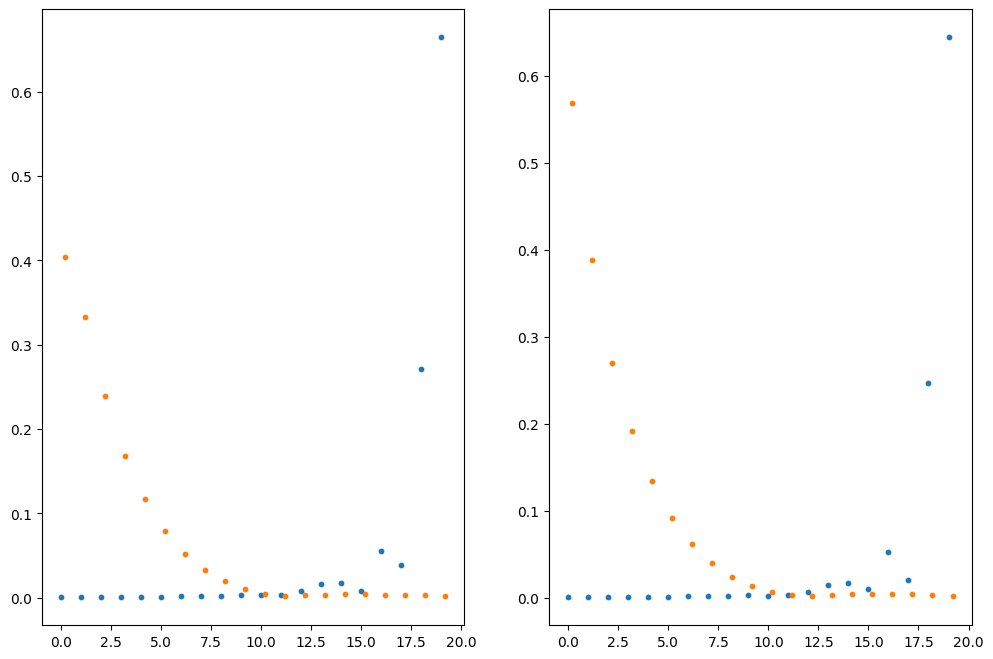

In [ ]:
# print eigenstates
head = 2
sublattice =0
space_direction =0
start = (space_direction+sublattice*3)*grid_size
stop = start+grid_size+1
bandcut_up = 6*grid_size
bandcut_down = 0*grid_size
tot_A = np.sqrt(np.abs(eigenvecs2[:,bandcut_down:bandcut_up,1:grid_size+1])**2+ np.abs(eigenvecs2[:,bandcut_down:bandcut_up,1+grid_size:2*grid_size+1])**2 + np.abs(eigenvecs2[:,bandcut_down:bandcut_up,1+2*grid_size:3*grid_size+1])**2)
tot_B = np.sqrt(np.abs(eigenvecs2[:,bandcut_down:bandcut_up,1+3*grid_size:4*grid_size+1])**2 + np.abs(eigenvecs2[:,bandcut_down:bandcut_up,1+4*grid_size:5*grid_size+1])**2 + np.abs(eigenvecs2[:,bandcut_down:bandcut_up,1+5*grid_size:6*grid_size+1])**2)
# print(np.sum(np.absolute(tot_A)**2+np.absolute(tot_B)**2,axis=2))
for i in range(10):
    # sublattice =0 
    # space_direction =0
    # normalizedA = np.transpose(eigenvecs2[i,:,1+start:stop].T/np.max(np.absolute(eigenvecs2[i,:,1+start:stop].T),axis=0))
    # for space_direction in range(1,3):
    #     start = (space_direction+sublattice*3)*grid_size
    #     stop = start+grid_size+1
    #     normalizedA += np.transpose(eigenvecs2[i,:,1+start:stop].T/np.max(np.absolute(eigenvecs2[i,:,1+start:stop].T),axis=0))

    normalizedA = np.absolute(eigenvecs2[i,:,1:]) #np.transpose(tot_A[i,:,:].T/np.max(np.absolute(tot_B[i,:,:].T**2+tot_A[i,:,:].T**2),axis=0))
    sumupA = np.sum(np.absolute(normalizedA),axis=1)#- np.absolute(normalizedA)[:,0]- np.absolute(normalizedA)[:,-1]
    integral_rankA = np.column_stack((sumupA, np.arange(len(sumupA)))) 
    
    integral_rankA = sorted(integral_rankA, key=lambda x: x[0])


    normalizedB = np.transpose(tot_B[i,:,:].T/np.max(np.absolute(tot_B[i,:,:].T**2+tot_A[i,:,:].T**2),axis=0))
    sumupB = np.sum(np.absolute(normalizedB),axis=1)#- np.absolute(normalizedB)[:,0]- np.absolute(normalizedB)[:,-1]
    # print(np.sum(np.absolute(normalizedB)**2+np.absolute(normalizedA)**2,axis=1))
    integral_rankB = np.column_stack((sumupB, np.arange(len(sumupB)))) 
    
    integral_rankB = sorted(integral_rankB, key=lambda x: x[0])

    # sublattice =1
    # space_direction =0
    # normalizedB = np.transpose(eigenvecs2[i,:,1+start:stop].T/np.max(np.absolute(eigenvecs2[i,:,1+start:stop].T),axis=0))**2
    # for space_direction in range(1,3):
    #     normalizedB += np.transpose(eigenvecs2[i,:,1+start:stop].T/np.max(np.absolute(eigenvecs2[i,:,1+start:stop].T),axis=0))**2
    # normalizedB = np.sqrt(normalizedB)
    # sumup = np.sum(np.absolute(normalizedB),axis=1)- np.absolute(normalizedB)[:,0]- np.absolute(normalizedB)[:,-1]
    # integral_rankB = np.column_stack((sumup, np.arange(len(sumup)))) 
    
    # integral_rankB = sorted(integral_rankB, key=lambda x: x[0])
    fig, ax = plt.subplots(1,2,figsize=(12, 8))
    # print(integral_rankA[index][1])
    
    for index in range(head):
        print(eigenvecs2[i,int(integral_rankA[index][1]),0])
        ax[0].scatter(index*0.2+np.arange(grid_size), tot_A[i,int(integral_rankA[index][1]),:],s=10)#,alpha=0.5,color='red')
        ax[1].scatter(index*0.2+np.arange(grid_size), tot_B[i,int(integral_rankA[index][1]),:],s=10)
        # ax[1].scatter(index*0.2+np.arange(grid_size), np.abs(normalized[int(integral_rank[index][1]),:]),s=10)
    plt.show()


In [ ]:
eigenvals.shape[:2]
ky = np.zeros(eigenvals.shape[:2])

kx = np.zeros_like(ky)
# Make data
for i in range(-(k_size//2),k_size//2+1):
    for j in range(-(k_size//2),k_size//2+1):

        k = i/k_size * REZI_1 + j/k_size * REZI_2
        ky[i,j] = k[1]
        kx[i,j] = k[0]

k = np.stack((kx,ky))
import os
os.makedirs("3D_data", exist_ok=True)
np.save("3D_data/k_periodic_dipole5.npy",k)
np.save("3D_data/periodic_dipole_eigenvalues5.npy",eigenvals[:,:,:,0])

/home/christian/Documents/master/python_env/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


<Figure size 200x200 with 0 Axes>

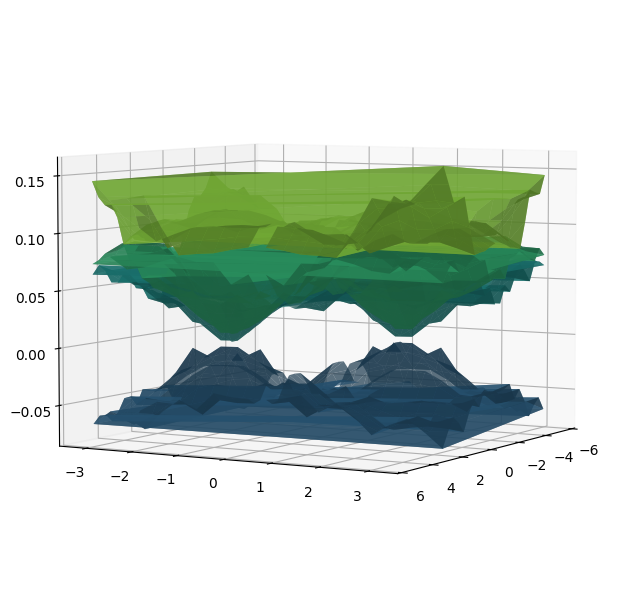

In [12]:
# 3D plot of eigenenergies


from matplotlib import cm

plt.style.use('_mpl-gallery')
ky = np.zeros(eigenvals.shape[:2])

kx = np.zeros_like(ky)
# Make data
for i in range(-(k_size//2),k_size//2+1):
    for j in range(-(k_size//2),k_size//2+1):

        k = i/k_size * REZI_1 + j/k_size * REZI_2
        ky[i,j] = k[1]
        kx[i,j] = k[0]
# ky = np.arange(-(k_size//2),k_size//2+1)/k_size * k1[1]
plt.figure()

fig, ax = plt.subplots(subplot_kw={"projection": "3d"},figsize=(8, 6))
for i in range(2,eigenvals.shape[2]):
    ax.plot_surface(kx, ky, eigenvals[:,:,i,0],color=cm.viridis(i/eigenvals.shape[2]), alpha=0.7)
ax.view_init(elev=5, azim=30)

plt.show()